# Catatan Revisi

Notebook ini adalah versi revisi dari pipeline BERT hierarchical + LSTM + fitur
stylometric/POS untuk deteksi teks Human vs AI.

## Revisi tahap 1 (threshold & diagnosis domain-shift)
1. **KONFIGURASI** — `TARGET_AI_FALSE_POSITIVE_RATE` & `TARGET_HUMAN_FALSE_NEGATIVE_RATE`
   dinaikkan dari 0.01 -> 0.02, ditambah `THRESHOLD_SAFETY_MARGIN = 0.01` agar
   threshold AI/Human tidak terlalu ekstrem/borderline.
2. **MIN_WORDS_FOR_PREDICTION** (50->100) & **FORCE_UNCERTAIN_BELOW_WORDS** (80->200)
   dinaikkan supaya teks pendek (hanya menghasilkan 1 chunk BERT) tidak dipaksa
   jadi keputusan tegas Human/AI.
3. Sel baru **CEK DOMAIN / GENRE DATASET** ditambahkan setelah `load_dataset()`
   untuk membantu diagnosis domain-mismatch antara data training dan teks uji baru.
4. Sel **threshold selection** (`select_ai_threshold` / `select_human_threshold`)
   ditambah margin keamanan sebelum threshold final dipakai.
5. Sel **TESTING** di akhir notebook sekarang menguji 3 kasus sekaligus (Human
   dari test set, AI dari test set, teks baru di luar dataset) supaya bias/
   domain-shift terlihat jelas, bukan cuma satu contoh teks.

## Revisi tahap 2 (kualitas & kredibilitas model)
6. **Fitur perplexity & burstiness** ditambahkan ke `extract_linguistic_features`
   memakai causal LM kecil (`distilgpt2` secara default, ganti ke model GPT-2
   Indonesia kalau datasetnya Indonesia). Dimensi fitur stylometric naik dari
   12 -> 14 (`LINGUISTIC_FEATURE_DIM` menyesuaikan otomatis).
7. Sel baru **"25. K-Fold Cross-Validation (Opsional)"** ditambahkan di akhir
   (sebelum bagian testing teks baru). Set `RUN_KFOLD_CV = True` di KONFIGURASI
   untuk menjalankan; hasilnya berupa mean ± std accuracy/precision/recall/F1/
   ROC-AUC lintas fold, disimpan ke `kfold_cv_results.csv`. Memakai
   `StratifiedGroupKFold` dengan `group_id` supaya tidak ada leakage
   near-duplicate antar fold, konsisten dengan split utama.

Jalankan notebook dari awal (Run All) karena beberapa output lama sudah dihapus
setelah perubahan konfigurasi. K-Fold CV (langkah 7) opsional dan menambah waktu
training signifikan (default nonaktif, `RUN_KFOLD_CV = False`).


# Install Library

In [2]:
# !pip -q install "transformers>=4.44,<5" "accelerate>=0.30,<2" "datasketch>=1.6,<2" "spacy>=3.7,<4"
# !python -m spacy download en_core_web_sm -q

# Import Library


In [3]:
import os
import re
import gc
import json
import math
import random
import shutil
import hashlib
import warnings
import unicodedata
from pathlib import Path
from itertools import chain

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler,
)
from torch.nn.utils.rnn import pack_padded_sequence

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForCausalLM,
    get_linear_schedule_with_warmup,
)
import torch.nn.functional as F

from sklearn.model_selection import (
    train_test_split,
    StratifiedGroupKFold,
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    log_loss,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve

from datasketch import MinHash, MinHashLSH
from tqdm.auto import tqdm

import spacy

warnings.filterwarnings("ignore")

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU     :", torch.cuda.get_device_name(0))
else:
    print("Aktifkan T4 GPU sebelum training.")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


# KONFIGURASI

In [4]:
# ==========================================================
# KONFIGURASI UTAMA
# ==========================================================

SEED = 42

# Tetap memakai BERT, bukan DistilBERT.
MODEL_NAME = "bert-base-uncased"

# Preprocessing
TEXT_MODE = "clean"  # "clean" atau "raw"

# Hierarchical document encoding
CHUNK_LENGTH = 256
CHUNK_STRIDE = 192
MAX_CHUNKS = 4
CHUNK_POOLING = "mean"  # "mean" atau "cls"

# Training
BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 4
EPOCHS = 10
PATIENCE = 2
MIN_IMPROVEMENT = 1e-4

LSTM_HIDDEN_SIZE = 128
LSTM_NUM_LAYERS = 1
DROPOUT = 0.40

LEARNING_RATE_BERT = 1e-5
LEARNING_RATE_HEAD = 5e-5
WEIGHT_DECAY = 0.02
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 1.0

# Epoch 1: hanya LSTM + classifier.
# Epoch berikutnya: BERT ikut di-fine-tune.
FREEZE_BERT_EPOCHS = 1

# Menghemat memori ketika BERT ikut dilatih.
ENABLE_GRADIENT_CHECKPOINTING = True

# Split sekitar 70/15/15
TEST_SIZE = 0.15
VAL_SIZE_FROM_TOTAL = 0.15

# Balancing hanya training:
# "none", "class_weight", "undersample",
# "oversample", "weighted_sampler"
#
# Dataset 61:39 belum terlalu ekstrem.
# class_weight dipilih agar seluruh data tetap digunakan
# tanpa mengubah prior sampling terlalu kuat.
BALANCE_STRATEGY = "class_weight"

# Exact duplicate selalu dihapus.
# Near-duplicate optional karena dapat memerlukan waktu cukup lama.
ENABLE_NEAR_DUPLICATE_GROUPING = True
NEAR_DUPLICATE_THRESHOLD = 0.90
MINHASH_NUM_PERM = 64
MINHASH_WORD_NGRAM = 3
DROP_CONFLICTING_GROUPS = True

# Calibration
USE_TEMPERATURE_SCALING = True

# Tiga zona keputusan dari validation set.
# Dinaikkan dari 0.01 -> 0.02 supaya threshold AI/Human tidak terlalu ekstrem
# (versi 0.01 menghasilkan threshold AI = 0.9825, sangat rawan pada teks
# out-of-domain / pendek karena hanya beda tipis dari probabilitas aktual).
TARGET_AI_FALSE_POSITIVE_RATE = 0.02
TARGET_HUMAN_FALSE_NEGATIVE_RATE = 0.02

# Margin tambahan di atas/bawah threshold hasil select_ai_threshold /
# select_human_threshold, supaya kasus borderline (mis. probability_ai
# hanya sedikit di atas threshold) jatuh ke "Uncertain", bukan dipaksa AI/Human.
THRESHOLD_SAFETY_MARGIN = 0.01

# Input terlalu pendek tidak dipaksa diklasifikasikan.
# Dinaikkan karena teks < ~100-200 kata biasanya hanya menghasilkan 1 chunk BERT
# sehingga representasi semantic dan fitur stylometric/POS kurang stabil.
MIN_WORDS_FOR_PREDICTION = 100
FORCE_UNCERTAIN_BELOW_WORDS = 120

# Optional ablation:
# Baseline memakai BERT chunk vectors + mean pooling antar-chunk,
# tanpa LSTM. Aktifkan untuk membuktikan kontribusi LSTM.
RUN_BERT_MEAN_BASELINE = False

# Perplexity / burstiness (LLM-likelihood) feature.
# Teks AI cenderung punya perplexity rendah & konsisten (predictable oleh LM),
# sementara teks manusia lebih "bursty" (variasi tinggi antar token/kalimat).
# Ganti PERPLEXITY_MODEL_NAME ke model bahasa Indonesia (mis. causal LM
# berbasis GPT-2 Indonesia) kalau dataset berbahasa Indonesia.
ENABLE_PERPLEXITY_FEATURES = True
PERPLEXITY_MODEL_NAME = "distilgpt2"
PERPLEXITY_MAX_TOKENS = 512  # batasi panjang teks yang dihitung agar cepat

# K-Fold Cross-Validation (opsional, lihat bagian akhir notebook).
# Dijalankan terpisah dari training utama single-split di atas -- tidak
# menggantikan train/val/test split, hanya untuk memvalidasi stabilitas
# performa model di beberapa pembagian data yang berbeda.
RUN_KFOLD_CV = False  # set True untuk menjalankan (menambah waktu training signifikan)
N_FOLDS = 5
KFOLD_EPOCHS = 2  # epoch per fold sengaja lebih sedikit dari EPOCHS utama

# Runtime
NUM_WORKERS = 2
USE_AMP = True
ENCODING_BATCH_SIZE = 128

OUTPUT_DIR = Path(
    "/kaggle/working/bert_hierarchical_lstm_final"
)
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


seed_everything(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

AMP_ENABLED = bool(
    USE_AMP and DEVICE.type == "cuda"
)

print("Device           :", DEVICE)
print("Model            :", MODEL_NAME)
print("Chunk length     :", CHUNK_LENGTH)
print("Max chunks       :", MAX_CHUNKS)
print("Chunk pooling    :", CHUNK_POOLING)
print("Balance strategy :", BALANCE_STRATEGY)

Device           : cuda
Model            : bert-base-uncased
Chunk length     : 256
Max chunks       : 4
Chunk pooling    : mean
Balance strategy : class_weight


# UPLOAD DATASET

In [5]:
# Isi path manual jika dataset sudah berada di Drive atau /content.
# Contoh:
# DATA_PATH = "/content/drive/MyDrive/dataset/human_ai.csv"
DATA_PATH = "/kaggle/input/datasets/fransisca27/dataset-human-ai-written-merged/data_merged_micusp_ai.xlsx"

if DATA_PATH is None:
    try:
        from google.colab import files

        uploaded = files.upload()
        uploaded_names = list(uploaded.keys())

        csv_candidates = [
            name
            for name in uploaded_names
            if name.lower().endswith(".csv")
        ]

        excel_candidates = [
            name
            for name in uploaded_names
            if name.lower().endswith(
                (".xlsx", ".xls")
            )
        ]

        if csv_candidates:
            DATA_PATH = csv_candidates[0]
        elif excel_candidates:
            DATA_PATH = excel_candidates[0]
        else:
            raise ValueError(
                "Upload file CSV, XLSX, atau XLS."
            )

    except ImportError:
        raise RuntimeError(
            "Isi DATA_PATH secara manual jika tidak memakai Colab."
        )

print("Dataset:", DATA_PATH)

Dataset: /kaggle/input/datasets/fransisca27/dataset-human-ai-written-merged/data_merged_micusp_ai.xlsx


In [6]:
def load_dataset(path):
    path = str(path)
    suffix = Path(path).suffix.lower()

    if suffix == ".csv":
        data = pd.read_csv(
            path,
            low_memory=False,
        )
    elif suffix in {".xlsx", ".xls"}:
        data = pd.read_excel(path)
    else:
        raise ValueError(
            f"Format tidak didukung: {suffix}"
        )

    data.columns = [
        str(column).strip().lower()
        for column in data.columns
    ]

    required_columns = {
        "text",
        "label",
    }

    missing_columns = (
        required_columns
        .difference(data.columns)
    )

    if missing_columns:
        raise ValueError(
            "Kolom wajib tidak ditemukan: "
            f"{sorted(missing_columns)}"
        )

    return data[
        ["text", "label"]
    ].copy()


df = load_dataset(DATA_PATH)

print("Ukuran awal:", df.shape)
display(df.head())

Ukuran awal: (47388, 2)


,text,label
0,Phones\n\nModern humans today are always on th...,0
1,This essay will explain if drivers should or s...,0
2,Driving while the use of cellular devices\n\nT...,0
3,Phones & Driving\n\nDrivers should not be able...,0
4,Cell Phone Operation While Driving\n\nThe abil...,0


# CLEANING AND NORMALIZATION LABEL

In [7]:
def normalize_label(value):
    if pd.isna(value):
        return np.nan

    if isinstance(
        value,
        (int, np.integer, float, np.floating),
    ):
        numeric_value = int(value)
        return (
            numeric_value
            if numeric_value in (0, 1)
            else np.nan
        )

    value = str(value).strip().lower()

    human_labels = {
        "0",
        "human",
        "human-written",
        "human written",
        "real",
        "person",
        "student",
    }

    ai_labels = {
        "1",
        "ai",
        "ai-generated",
        "ai generated",
        "machine",
        "llm",
        "chatgpt",
    }

    if value in human_labels:
        return 0

    if value in ai_labels:
        return 1

    return np.nan


def minimal_clean_text(text):
    """
    Cleaning konservatif.

    Tidak menghapus:
    - tanda baca;
    - kapitalisasi;
    - typo;
    - stopword;
    - struktur kalimat;
    - paragraf.

    Hanya menormalkan:
    - Unicode;
    - karakter kontrol;
    - spasi/newline berlebih.
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = unicodedata.normalize(
        "NFKC",
        text,
    )

    text = text.replace(
        "\u00a0",
        " ",
    )
    text = text.replace(
        "\r\n",
        "\n",
    )
    text = text.replace(
        "\r",
        "\n",
    )

    text = "".join(
        character
        for character in text
        if (
            character in "\n\t"
            or not unicodedata.category(
                character
            ).startswith("C")
        )
    )

    text = re.sub(
        r"[ \t]+",
        " ",
        text,
    )
    text = re.sub(
        r" *\n *",
        "\n",
        text,
    )
    text = re.sub(
        r"\n{3,}",
        "\n\n",
        text,
    )

    return text.strip()


def normalized_text_for_hash(text):
    normalized = unicodedata.normalize(
        "NFKC",
        str(text),
    ).lower()

    normalized = re.sub(
        r"\s+",
        " ",
        normalized,
    ).strip()

    return normalized


def make_text_hash(text):
    normalized = normalized_text_for_hash(
        text
    )

    return hashlib.sha256(
        normalized.encode("utf-8")
    ).hexdigest()


df = df.copy()

df["label"] = df[
    "label"
].apply(normalize_label)

df["text_raw"] = (
    df["text"]
    .fillna("")
    .astype(str)
)

df["text_clean"] = (
    df["text_raw"]
    .apply(minimal_clean_text)
)

before_invalid = len(df)

df = df[
    df["label"].isin([0, 1])
    & df["text_clean"].str.len().gt(0)
].copy()

df["label"] = df[
    "label"
].astype(int)

print(
    "Baris invalid/kosong dibuang:",
    before_invalid - len(df),
)

Baris invalid/kosong dibuang: 0


# CEK DOMAIN / GENRE DATASET (diagnosis)

In [8]:
# Menampilkan beberapa contoh teks per kelas untuk memahami genre/domain
# dataset training. Berguna untuk mendiagnosis potensi domain-mismatch ketika
# model diuji dengan teks baru di luar dataset (mis. berita, artikel bebas
# topik) yang mungkin bergaya berbeda dari data training.

print("Contoh teks Human (label 0):")
for text in df.loc[df["label"] == 0, "text_raw"].sample(3, random_state=SEED):
    print("-", text[:200].replace("\n", " "), "...")

print()
print("Contoh teks AI (label 1):")
for text in df.loc[df["label"] == 1, "text_raw"].sample(3, random_state=SEED):
    print("-", text[:200].replace("\n", " "), "...")


Contoh teks Human (label 0):
- The anachronism that is the electoral college is a system that unfairly represents voters and can possibly lead to catastrophe. The much simpler solution would be election by popular vote where every  ...
- Have you ever wanted to go around the world or see it. Well now you can with the Seagoing Cowboys program you get to go all around the world and ride waves, and boats and see a hole nother adventue wa ...
- A computer shouldn't be able to tell peoples emotions. Having emotions is a very personal thing between you and only you or if you choose to share them with others. Thats what makes people so real and ...

Contoh teks AI (label 1):
- Hey, so like, I know that knowledge is super important for, like, success in life and stuff. I mean, think about it, without knowledge, we wouldn't be able to do anything. Like, we wouldn't be able to ...
- "The Challenge of Exploring Venus" is a compelling article that argues that despite the dangers, studying Venus is

# EXACT DUPLICATE REMOVAL

In [9]:
df["text_hash"] = (
    df["text_clean"]
    .apply(make_text_hash)
)

before_deduplication = len(df)

df = (
    df.drop_duplicates(
        subset=["text_hash"],
        keep="first",
    )
    .reset_index(drop=True)
)

print(
    "Exact duplicate dibuang:",
    before_deduplication - len(df),
)
print(
    "Ukuran setelah deduplikasi:",
    df.shape,
)

distribution = (
    df["label"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Human (0)",
            1: "AI (1)",
        }
    )
    .to_frame("jumlah")
)

distribution["persentase"] = (
    100
    * distribution["jumlah"]
    / distribution["jumlah"].sum()
).round(2)

display(distribution)

Exact duplicate dibuang: 11
Ukuran setelah deduplikasi: (47377, 5)


,jumlah,persentase
label,,
Human (0),28620,60.41
AI (1),18757,39.59


# OPTIONAL NEAR-DUPLICATE GROUPING

In [10]:
class UnionFind:
    def __init__(self, size):
        self.parent = list(range(size))
        self.rank = [0] * size

    def find(self, item):
        while (
            self.parent[item] != item
        ):
            self.parent[item] = (
                self.parent[
                    self.parent[item]
                ]
            )
            item = self.parent[item]

        return item

    def union(self, first, second):
        root_first = self.find(first)
        root_second = self.find(second)

        if root_first == root_second:
            return

        if (
            self.rank[root_first]
            < self.rank[root_second]
        ):
            self.parent[root_first] = (
                root_second
            )

        elif (
            self.rank[root_first]
            > self.rank[root_second]
        ):
            self.parent[root_second] = (
                root_first
            )

        else:
            self.parent[root_second] = (
                root_first
            )
            self.rank[root_first] += 1


def word_ngrams(
    text,
    ngram_size=3,
):
    words = normalized_text_for_hash(
        text
    ).split()

    if len(words) <= ngram_size:
        return {
            " ".join(words)
        }

    return {
        " ".join(
            words[index:index + ngram_size]
        )
        for index in range(
            len(words) - ngram_size + 1
        )
    }


def create_minhash(
    shingles,
    num_perm=64,
):
    minhash = MinHash(
        num_perm=num_perm
    )

    for shingle in shingles:
        minhash.update(
            shingle.encode("utf-8")
        )

    return minhash


def create_near_duplicate_groups(
    texts,
    threshold=0.90,
    num_perm=64,
    word_ngram_size=3,
):
    union_find = UnionFind(
        len(texts)
    )

    lsh = MinHashLSH(
        threshold=threshold,
        num_perm=num_perm,
    )

    for index, text in enumerate(
        tqdm(
            texts,
            desc="Near-duplicate grouping",
        )
    ):
        shingles = word_ngrams(
            text,
            ngram_size=word_ngram_size,
        )

        minhash = create_minhash(
            shingles,
            num_perm=num_perm,
        )

        candidates = lsh.query(
            minhash
        )

        for candidate in candidates:
            union_find.union(
                index,
                int(candidate),
            )

        lsh.insert(
            str(index),
            minhash,
        )

    roots = [
        union_find.find(index)
        for index in range(len(texts))
    ]

    root_to_group = {}
    group_ids = []

    for root in roots:
        if root not in root_to_group:
            root_to_group[root] = (
                len(root_to_group)
            )

        group_ids.append(
            root_to_group[root]
        )

    return np.asarray(group_ids)


if ENABLE_NEAR_DUPLICATE_GROUPING:
    df["group_id"] = (
        create_near_duplicate_groups(
            df["text_clean"].tolist(),
            threshold=(
                NEAR_DUPLICATE_THRESHOLD
            ),
            num_perm=MINHASH_NUM_PERM,
            word_ngram_size=(
                MINHASH_WORD_NGRAM
            ),
        )
    )

    conflicting_groups = (
        df.groupby("group_id")["label"]
        .nunique()
    )

    conflicting_groups = set(
        conflicting_groups[
            conflicting_groups > 1
        ].index
    )

    print(
        "Jumlah conflicting groups:",
        len(conflicting_groups),
    )

    if (
        DROP_CONFLICTING_GROUPS
        and conflicting_groups
    ):
        before_conflict_drop = len(df)

        df = df[
            ~df["group_id"].isin(
                conflicting_groups
            )
        ].copy()

        print(
            "Baris conflicting dibuang:",
            before_conflict_drop - len(df),
        )

    df = df.reset_index(drop=True)

else:
    # Setiap exact unique document menjadi grup sendiri.
    df["group_id"] = np.arange(
        len(df)
    )

    print(
        "Near-duplicate grouping tidak diaktifkan."
    )

Near-duplicate grouping:   0%|          | 0/47377 [00:00<?, ?it/s]

Jumlah conflicting groups: 0


# DOCUMENT LENGTH ANALYSIS

,count,mean,std,min,50%,75%,90%,95%,99%,max
word_count,47377.0,452.239019,439.583289,4.0,358.0,474.0,680.0,923.0,2540.44,5357.0


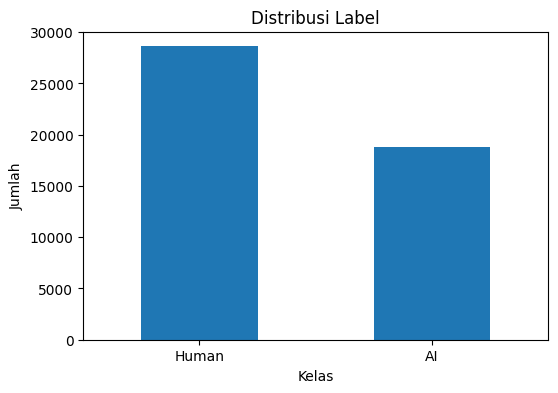

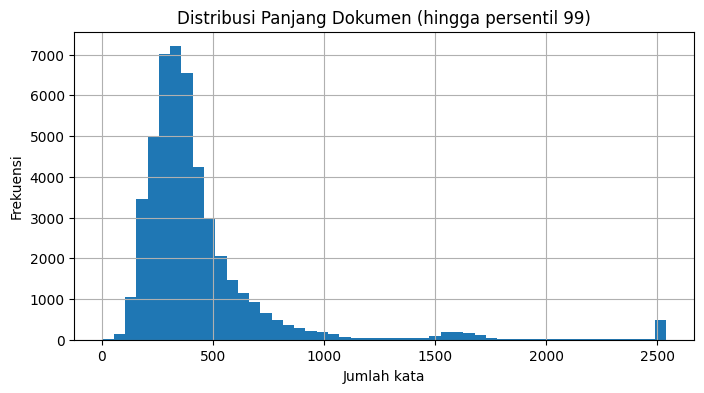

In [11]:
df["word_count"] = (
    df["text_clean"]
    .str.split()
    .str.len()
)

display(
    df["word_count"]
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .to_frame()
    .T
)

plt.figure(figsize=(6, 4))

df["label"].map(
    {
        0: "Human",
        1: "AI",
    }
).value_counts().plot(
    kind="bar"
)

plt.title("Distribusi Label")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8, 4))

upper_limit = (
    df["word_count"]
    .quantile(0.99)
)

df["word_count"].clip(
    upper=upper_limit
).hist(
    bins=50
)

plt.title(
    "Distribusi Panjang Dokumen "
    "(hingga persentil 99)"
)
plt.xlabel("Jumlah kata")
plt.ylabel("Frekuensi")
plt.show()

# Group-aware train, validation, dan test split

In [12]:
def standard_stratified_split(
    data,
):
    train_val, test = train_test_split(
        data,
        test_size=TEST_SIZE,
        stratify=data["label"],
        random_state=SEED,
    )

    relative_validation_size = (
        VAL_SIZE_FROM_TOTAL
        / (1.0 - TEST_SIZE)
    )

    train, validation = (
        train_test_split(
            train_val,
            test_size=(
                relative_validation_size
            ),
            stratify=train_val["label"],
            random_state=SEED,
        )
    )

    return train, validation, test


def grouped_stratified_split(
    data,
):
    first_splitter = (
        StratifiedGroupKFold(
            n_splits=7,
            shuffle=True,
            random_state=SEED,
        )
    )

    train_val_indices, test_indices = (
        next(
            first_splitter.split(
                data,
                y=data["label"],
                groups=data["group_id"],
            )
        )
    )

    train_val = data.iloc[
        train_val_indices
    ].copy()

    test = data.iloc[
        test_indices
    ].copy()

    second_splitter = (
        StratifiedGroupKFold(
            n_splits=6,
            shuffle=True,
            random_state=SEED + 1,
        )
    )

    train_indices, validation_indices = (
        next(
            second_splitter.split(
                train_val,
                y=train_val["label"],
                groups=train_val["group_id"],
            )
        )
    )

    train = train_val.iloc[
        train_indices
    ].copy()

    validation = train_val.iloc[
        validation_indices
    ].copy()

    return train, validation, test


if ENABLE_NEAR_DUPLICATE_GROUPING:
    train_df, val_df, test_df = (
        grouped_stratified_split(df)
    )
else:
    train_df, val_df, test_df = (
        standard_stratified_split(df)
    )


def select_model_text(data):
    data = data.copy()

    if TEXT_MODE == "clean":
        data["model_text"] = (
            data["text_clean"]
        )
    elif TEXT_MODE == "raw":
        data["model_text"] = (
            data["text_raw"]
        )
    else:
        raise ValueError(
            "TEXT_MODE harus clean atau raw."
        )

    return data.reset_index(drop=True)


train_df = select_model_text(
    train_df
)
val_df = select_model_text(
    val_df
)
test_df = select_model_text(
    test_df
)


def summarize_split(name, data):
    counts = (
        data["label"]
        .value_counts()
    )

    return {
        "split": name,
        "jumlah": len(data),
        "human": int(
            counts.get(0, 0)
        ),
        "ai": int(
            counts.get(1, 0)
        ),
        "human_%": round(
            100
            * counts.get(0, 0)
            / len(data),
            2,
        ),
        "ai_%": round(
            100
            * counts.get(1, 0)
            / len(data),
            2,
        ),
    }


display(
    pd.DataFrame(
        [
            summarize_split(
                "Train",
                train_df,
            ),
            summarize_split(
                "Validation",
                val_df,
            ),
            summarize_split(
                "Test",
                test_df,
            ),
        ]
    )
)

assert not set(
    train_df["text_hash"]
).intersection(
    val_df["text_hash"]
)

assert not set(
    train_df["text_hash"]
).intersection(
    test_df["text_hash"]
)

assert not set(
    val_df["text_hash"]
).intersection(
    test_df["text_hash"]
)

if ENABLE_NEAR_DUPLICATE_GROUPING:
    assert not set(
        train_df["group_id"]
    ).intersection(
        val_df["group_id"]
    )

    assert not set(
        train_df["group_id"]
    ).intersection(
        test_df["group_id"]
    )

    assert not set(
        val_df["group_id"]
    ).intersection(
        test_df["group_id"]
    )

print(
    "Pemeriksaan leakage antar-split: AMAN"
)

,split,jumlah,human,ai,human_%,ai_%
0,Train,33832,20434,13398,60.40,39.60
1,Validation,6774,4094,2680,60.44,39.56
2,Test,6771,4092,2679,60.43,39.57


Pemeriksaan leakage antar-split: AMAN


# BALANCING TRAINING SET

In [13]:
def class_distribution_table(
    data,
    dataset_name,
):
    counts = (
        data["label"]
        .value_counts()
    )

    total = len(data)

    return pd.DataFrame(
        {
            "dataset": [
                dataset_name,
                dataset_name,
            ],
            "kelas": [
                "Human (0)",
                "AI (1)",
            ],
            "jumlah": [
                int(counts.get(0, 0)),
                int(counts.get(1, 0)),
            ],
            "persentase": [
                round(
                    100
                    * counts.get(0, 0)
                    / max(total, 1),
                    2,
                ),
                round(
                    100
                    * counts.get(1, 0)
                    / max(total, 1),
                    2,
                ),
            ],
        }
    )


def balance_training_dataframe(
    data,
    strategy,
    seed=42,
):
    valid_strategies = {
        "none",
        "class_weight",
        "undersample",
        "oversample",
        "weighted_sampler",
    }

    if strategy not in valid_strategies:
        raise ValueError(
            f"Strategi tidak valid: {strategy}"
        )

    data = data.copy().reset_index(
        drop=True
    )

    if strategy in {
        "none",
        "class_weight",
        "weighted_sampler",
    }:
        return data

    human_data = data[
        data["label"] == 0
    ].copy()

    ai_data = data[
        data["label"] == 1
    ].copy()

    if (
        human_data.empty
        or ai_data.empty
    ):
        raise ValueError(
            "Training harus memiliki dua kelas."
        )

    if strategy == "undersample":
        target_size = min(
            len(human_data),
            len(ai_data),
        )

        human_balanced = (
            human_data.sample(
                n=target_size,
                replace=False,
                random_state=seed,
            )
        )

        ai_balanced = (
            ai_data.sample(
                n=target_size,
                replace=False,
                random_state=seed,
            )
        )

    elif strategy == "oversample":
        target_size = max(
            len(human_data),
            len(ai_data),
        )

        human_balanced = (
            human_data.sample(
                n=target_size,
                replace=(
                    len(human_data)
                    < target_size
                ),
                random_state=seed,
            )
        )

        ai_balanced = (
            ai_data.sample(
                n=target_size,
                replace=(
                    len(ai_data)
                    < target_size
                ),
                random_state=seed,
            )
        )

    balanced = pd.concat(
        [
            human_balanced,
            ai_balanced,
        ],
        ignore_index=True,
    )

    return (
        balanced.sample(
            frac=1.0,
            random_state=seed,
        )
        .reset_index(drop=True)
    )


train_df_before_balance = (
    train_df.copy()
)

train_df = (
    balance_training_dataframe(
        train_df,
        strategy=BALANCE_STRATEGY,
        seed=SEED,
    )
)

display(
    pd.concat(
        [
            class_distribution_table(
                train_df_before_balance,
                "Train sebelum balancing",
            ),
            class_distribution_table(
                train_df,
                "Train setelah balancing",
            ),
            class_distribution_table(
                val_df,
                "Validation asli",
            ),
            class_distribution_table(
                test_df,
                "Test asli",
            ),
        ],
        ignore_index=True,
    )
)

print(
    "Strategi balancing:",
    BALANCE_STRATEGY,
)

,dataset,kelas,jumlah,persentase
0,Train sebelum balancing,Human (0),20434,60.40
1,Train sebelum balancing,AI (1),13398,39.60
2,Train setelah balancing,Human (0),20434,60.40
3,Train setelah balancing,AI (1),13398,39.60
4,Validation asli,Human (0),4094,60.44
5,Validation asli,AI (1),2680,39.56
6,Test asli,Human (0),4092,60.43
7,Test asli,AI (1),2679,39.57


Strategi balancing: class_weight


# TOKENIZER AND HIERARCHICAL CHUNK ENCODING

In [14]:
tokenizer = (
    AutoTokenizer.from_pretrained(
        MODEL_NAME
    )
)

# Beberapa model (mis. keluarga GPT-2 / model berbasis decoder-only seperti
# IndoGPT) tidak punya pad_token bawaan -> pad_token_id bernilai None, yang
# bikin np.full(...) di encode_documents() error. BERT/IndoBERT normalnya
# sudah punya [PAD] sendiri, jadi fallback ini aman untuk semua kasus.
if tokenizer.pad_token_id is None:
    if tokenizer.eos_token is not None:
        tokenizer.pad_token = tokenizer.eos_token
    else:
        tokenizer.add_special_tokens(
            {"pad_token": "[PAD]"}
        )

# cls_token / sep_token juga tidak selalu ada di model non-BERT.
# Kalau MODEL_NAME diganti ke model tanpa CLS/SEP eksplisit, kode chunking
# di bawah (encode_document_chunks) yang memakai tokenizer.cls_token_id /
# tokenizer.sep_token_id perlu model dengan CLS/SEP token -- untuk model
# decoder-only seperti GPT-2, pipeline hierarchical-chunking ini TIDAK
# didesain ulang otomatis, jadi tetap disarankan pakai model encoder
# (BERT/IndoBERT/RoBERTa, dst.) untuk MODEL_NAME.

print(
    "Tokenizer:",
    tokenizer.__class__.__name__,
)
print(
    "Vocabulary:",
    tokenizer.vocab_size,
)
print(
    "CLS/PAD/SEP:",
    tokenizer.cls_token_id,
    tokenizer.pad_token_id,
    tokenizer.sep_token_id,
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: BertTokenizerFast
Vocabulary: 30522
CLS/PAD/SEP: 101 0 102


In [15]:
def select_evenly_spaced_indices(
    total_items,
    max_items,
):
    if total_items <= max_items:
        return list(range(total_items))

    selected = np.linspace(
        0,
        total_items - 1,
        num=max_items,
    )

    selected = np.round(
        selected
    ).astype(int)

    # Menjaga urutan dan menghapus duplikasi.
    return list(
        dict.fromkeys(
            selected.tolist()
        )
    )


def tokenize_document_to_chunks(
    text,
    tokenizer,
    chunk_length=256,
    stride=192,
    max_chunks=4,
):
    token_ids = list(
        tokenizer(
            text,
            add_special_tokens=False,
            truncation=False,
            return_attention_mask=False,
            return_token_type_ids=False,
        )["input_ids"]
    )

    special_tokens_count = (
        tokenizer.num_special_tokens_to_add(
            pair=False
        )
    )
    usable_length = (
        chunk_length - special_tokens_count
    )

    if usable_length <= 0:
        raise ValueError(
            "CHUNK_LENGTH terlalu kecil untuk "
            "special tokens tokenizer."
        )

    if not token_ids:
        fallback_token_id = next(
            (
                token_id
                for token_id in (
                    tokenizer.unk_token_id,
                    tokenizer.eos_token_id,
                    tokenizer.bos_token_id,
                    tokenizer.pad_token_id,
                )
                if token_id is not None
            ),
            None,
        )

        if fallback_token_id is None:
            raise ValueError(
                "Tokenizer tidak memiliki token ID "
                "untuk mewakili dokumen kosong."
            )

        token_ids = [fallback_token_id]

    if any(
        token_id is None
        for token_id in token_ids
    ):
        raise ValueError(
            "Tokenizer menghasilkan None di input_ids."
        )

    all_chunks = []

    for start in range(
        0,
        len(token_ids),
        stride,
    ):
        chunk = token_ids[
            start:start + usable_length
        ]

        if not chunk:
            break

        all_chunks.append(chunk)

        if (
            start + usable_length
            >= len(token_ids)
        ):
            break

    selected_indices = (
        select_evenly_spaced_indices(
            len(all_chunks),
            max_chunks,
        )
    )

    selected_chunks = [
        all_chunks[index]
        for index in selected_indices
    ]

    return {
        "chunks": selected_chunks,
        "total_chunks": len(all_chunks),
        "selected_indices": (
            selected_indices
        ),
    }


def encode_document_chunks(
    text,
    tokenizer,
    chunk_length=256,
    stride=192,
    max_chunks=4,
):
    chunk_data = (
        tokenize_document_to_chunks(
            text=text,
            tokenizer=tokenizer,
            chunk_length=chunk_length,
            stride=stride,
            max_chunks=max_chunks,
        )
    )

    if tokenizer.pad_token_id is None:
        raise ValueError(
            "pad_token_id belum dikonfigurasi. "
            "Jalankan ulang cell inisialisasi tokenizer."
        )

    input_ids = np.full(
        (
            max_chunks,
            chunk_length,
        ),
        int(tokenizer.pad_token_id),
        dtype=np.int32,
    )

    attention_mask = np.zeros(
        (
            max_chunks,
            chunk_length,
        ),
        dtype=np.int8,
    )

    chunk_mask = np.zeros(
        max_chunks,
        dtype=np.int8,
    )

    for chunk_index, chunk in enumerate(
        chunk_data["chunks"]
    ):
        sequence = (
            tokenizer.build_inputs_with_special_tokens(
                chunk[:chunk_length]
            )
        )

        if (
            len(sequence) > chunk_length
            or any(
                token_id is None
                for token_id in sequence
            )
        ):
            raise ValueError(
                "Special tokens tokenizer tidak valid "
                "untuk CHUNK_LENGTH yang dipilih."
            )

        sequence = [
            int(token_id)
            for token_id in sequence
        ]
        sequence_length = len(sequence)

        input_ids[
            chunk_index,
            :sequence_length,
        ] = sequence

        attention_mask[
            chunk_index,
            :sequence_length,
        ] = 1

        chunk_mask[chunk_index] = 1

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "chunk_mask": chunk_mask,
        "total_chunks": (
            chunk_data["total_chunks"]
        ),
        "selected_indices": (
            chunk_data["selected_indices"]
        ),
    }


def encode_documents(
    texts,
    description,
):
    number_of_documents = len(texts)

    all_input_ids = np.full(
        (
            number_of_documents,
            MAX_CHUNKS,
            CHUNK_LENGTH,
        ),
        tokenizer.pad_token_id,
        dtype=np.int32,
    )

    all_attention_mask = np.zeros(
        (
            number_of_documents,
            MAX_CHUNKS,
            CHUNK_LENGTH,
        ),
        dtype=np.int8,
    )

    all_chunk_mask = np.zeros(
        (
            number_of_documents,
            MAX_CHUNKS,
        ),
        dtype=np.int8,
    )

    total_chunks = np.zeros(
        number_of_documents,
        dtype=np.int16,
    )

    for index, text in enumerate(
        tqdm(
            texts,
            desc=description,
        )
    ):
        encoded = (
            encode_document_chunks(
                text=text,
                tokenizer=tokenizer,
                chunk_length=CHUNK_LENGTH,
                stride=CHUNK_STRIDE,
                max_chunks=MAX_CHUNKS,
            )
        )

        all_input_ids[index] = (
            encoded["input_ids"]
        )
        all_attention_mask[index] = (
            encoded["attention_mask"]
        )
        all_chunk_mask[index] = (
            encoded["chunk_mask"]
        )
        total_chunks[index] = (
            encoded["total_chunks"]
        )

    return {
        "input_ids": all_input_ids,
        "attention_mask": (
            all_attention_mask
        ),
        "chunk_mask": all_chunk_mask,
        "total_chunks": total_chunks,
    }


def make_encoding_cache_name(
    split_name,
    split_data,
):
    digest_source = "|".join(
        split_data[
            "text_hash"
        ].astype(str).tolist()
    )

    digest = hashlib.md5(
        digest_source.encode("utf-8")
    ).hexdigest()[:12]

    safe_model_name = (
        MODEL_NAME.replace("/", "_")
    )

    return (
        f"{split_name}_"
        f"{safe_model_name}_"
        f"{TEXT_MODE}_"
        f"L{CHUNK_LENGTH}_"
        f"S{CHUNK_STRIDE}_"
        f"C{MAX_CHUNKS}_"
        f"{digest}.npz"
    )


def encode_split_with_cache(
    split_data,
    split_name,
):
    cache_path = (
        OUTPUT_DIR
        / make_encoding_cache_name(
            split_name,
            split_data,
        )
    )

    if cache_path.exists():
        print(
            "Memuat cache:",
            cache_path.name,
        )

        cached = np.load(
            cache_path
        )

        return {
            "input_ids": (
                cached["input_ids"]
            ),
            "attention_mask": (
                cached["attention_mask"]
            ),
            "chunk_mask": (
                cached["chunk_mask"]
            ),
            "total_chunks": (
                cached["total_chunks"]
            ),
        }

    encoded = encode_documents(
        split_data[
            "model_text"
        ].tolist(),
        description=(
            f"Encoding {split_name}"
        ),
    )

    np.savez_compressed(
        cache_path,
        **encoded,
    )

    print(
        "Cache disimpan:",
        cache_path.name,
    )

    return encoded


train_encoded = (
    encode_split_with_cache(
        train_df,
        "train",
    )
)

val_encoded = (
    encode_split_with_cache(
        val_df,
        "validation",
    )
)

test_encoded = (
    encode_split_with_cache(
        test_df,
        "test",
    )
)

print(
    "Train input shape:",
    train_encoded[
        "input_ids"
    ].shape,
)
print(
    "Validation input shape:",
    val_encoded[
        "input_ids"
    ].shape,
)
print(
    "Test input shape:",
    test_encoded[
        "input_ids"
    ].shape,
)

Encoding train:   0%|          | 0/33832 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (551 > 512). Running this sequence through the model will result in indexing errors


Cache disimpan: train_bert-base-uncased_clean_L256_S192_C4_8b2922d3aa75.npz


Encoding validation:   0%|          | 0/6774 [00:00<?, ?it/s]

Cache disimpan: validation_bert-base-uncased_clean_L256_S192_C4_cbbfe9219a7e.npz


Encoding test:   0%|          | 0/6771 [00:00<?, ?it/s]

Cache disimpan: test_bert-base-uncased_clean_L256_S192_C4_1c8263ace50d.npz
Train input shape: (33832, 4, 256)
Validation input shape: (6774, 4, 256)
Test input shape: (6771, 4, 256)


In [16]:
coverage_summary = pd.DataFrame(
    {
        "split": [
            "Train",
            "Validation",
            "Test",
        ],
        "mean_total_chunks": [
            float(
                np.mean(
                    train_encoded[
                        "total_chunks"
                    ]
                )
            ),
            float(
                np.mean(
                    val_encoded[
                        "total_chunks"
                    ]
                )
            ),
            float(
                np.mean(
                    test_encoded[
                        "total_chunks"
                    ]
                )
            ),
        ],
        "documents_over_max_chunks": [
            int(
                np.sum(
                    train_encoded[
                        "total_chunks"
                    ] > MAX_CHUNKS
                )
            ),
            int(
                np.sum(
                    val_encoded[
                        "total_chunks"
                    ] > MAX_CHUNKS
                )
            ),
            int(
                np.sum(
                    test_encoded[
                        "total_chunks"
                    ] > MAX_CHUNKS
                )
            ),
        ],
    }
)

display(coverage_summary)

,split,mean_total_chunks,documents_over_max_chunks
0,Train,3.010818,3053
1,Validation,2.990847,610
2,Test,3.003249,599


In [17]:
# LINGUISTIC FEATURES: semantic (BERT), stylistic, POS, and perplexity/burstiness

# Parser dinonaktifkan agar lebih ringan, lalu diganti sentencizer
NLP = spacy.load(
    "en_core_web_sm",
    
    disable=["ner", "parser"]
)

if "sentencizer" not in NLP.pipe_names:
    NLP.add_pipe("sentencizer")

POS_TAGS = [
    "ADJ", "ADP", "ADV", "AUX",
    "CCONJ", "DET", "INTJ", "NOUN",
    "NUM", "PART", "PRON", "PROPN",
    "SCONJ", "SYM", "VERB", "X"
]

# --------------------------------------------------------------
# Perplexity / burstiness: pakai causal LM kecil (GPT-2) sebagai
# "detector" tambahan. Teks AI cenderung predictable buat LM
# (perplexity rendah, token-level surprisal konsisten/tidak bursty),
# sementara teks manusia lebih bervariasi. Ini teknik yang dipakai
# di riset AI-text-detection (mis. GLTR, DetectGPT).
# --------------------------------------------------------------

if ENABLE_PERPLEXITY_FEATURES:
    PERPLEXITY_TOKENIZER = AutoTokenizer.from_pretrained(
        PERPLEXITY_MODEL_NAME
    )

    if PERPLEXITY_TOKENIZER.pad_token is None:
        PERPLEXITY_TOKENIZER.pad_token = (
            PERPLEXITY_TOKENIZER.eos_token
        )

    PERPLEXITY_MODEL = AutoModelForCausalLM.from_pretrained(
        PERPLEXITY_MODEL_NAME
    ).to(DEVICE)

    PERPLEXITY_MODEL.eval()

    for parameter in PERPLEXITY_MODEL.parameters():
        parameter.requires_grad = False


@torch.no_grad()
def compute_perplexity_burstiness(text):
    # Mengembalikan (log_perplexity, burstiness).
    # burstiness = coefficient of variation dari token-level negative
    # log-likelihood -- proxy murah (1x forward pass) untuk variasi
    # "predictability" antar bagian dokumen, tanpa perlu loop per kalimat.
    if not ENABLE_PERPLEXITY_FEATURES or not text.strip():
        return 0.0, 0.0

    encoded = PERPLEXITY_TOKENIZER(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=PERPLEXITY_MAX_TOKENS,
    )

    input_ids = encoded["input_ids"].to(DEVICE)

    if input_ids.shape[1] < 2:
        return 0.0, 0.0

    outputs = PERPLEXITY_MODEL(input_ids)
    logits = outputs.logits

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]

    token_nll = F.cross_entropy(
        shift_logits.reshape(-1, shift_logits.size(-1)),
        shift_labels.reshape(-1),
        reduction="none",
    )

    token_nll = token_nll.detach().cpu().numpy()

    mean_nll = float(token_nll.mean())
    std_nll = float(token_nll.std())

    # Clip supaya exp() tidak overflow pada teks yang sangat tidak wajar.
    doc_perplexity = float(np.exp(min(mean_nll, 20.0)))
    burstiness = std_nll / (mean_nll + 1e-6)

    return np.log1p(doc_perplexity), burstiness


def extract_linguistic_features(text):
    text = "" if text is None else str(text)
    doc = NLP(text[:20000])

    tokens = [
        token for token in doc
        if not token.is_space
    ]

    words = [
        token for token in tokens
        if token.is_alpha
    ]

    word_texts = [
        token.text.lower()
        for token in words
    ]

    sentences = [
        sentence
        for sentence in doc.sents
        if sentence.text.strip()
    ]

    lengths = np.asarray(
        [
            len([
                token
                for token in sentence
                if token.is_alpha
            ])
            for sentence in sentences
        ],
        dtype=np.float32,
    )

    word_count = max(len(words), 1)
    char_count = max(len(text), 1)

    counts = (
        pd.Series(word_texts).value_counts()
        if word_texts
        else pd.Series(dtype=float)
    )

    pos_features = np.asarray(
        [
            sum(
                token.pos_ == tag
                for token in words
            ) / word_count
            for tag in POS_TAGS
        ],
        dtype=np.float32,
    )

    log_perplexity, burstiness = compute_perplexity_burstiness(text)

    style_features = np.asarray(
        [
            np.log1p(len(words)),
            np.log1p(len(sentences)),
            float(
                lengths.mean()
                if len(lengths) > 0
                else 0
            ),
            float(
                lengths.std()
                if len(lengths) > 0
                else 0
            ),
            len(set(word_texts)) / word_count,
            float(
                (counts == 1).sum()
                / word_count
            ),
            text.count(",") / char_count,
            text.count(";") / char_count,
            text.count(":") / char_count,
            sum(
                character in "!?"
                for character in text
            ) / char_count,
            sum(
                character.isupper()
                for character in text
            ) / char_count,
            text.count("\n\n") + 1,
            log_perplexity,
            burstiness,
        ],
        dtype=np.float32,
    )

    return np.concatenate(
        [
            style_features,
            pos_features,
        ]
    ).astype(np.float32)


def build_linguistic_matrix(dataframe):
    return np.vstack(
        [
            extract_linguistic_features(text)
            for text in tqdm(
                dataframe["text_raw"],
                desc="Extracting linguistic features",
            )
        ]
    ).astype(np.float32)


train_linguistic = build_linguistic_matrix(train_df)
val_linguistic = build_linguistic_matrix(val_df)
test_linguistic = build_linguistic_matrix(test_df)

linguistic_mean = train_linguistic.mean(axis=0)
linguistic_std = train_linguistic.std(axis=0)

linguistic_std[
    linguistic_std < 1e-6
] = 1.0

train_linguistic = (
    train_linguistic - linguistic_mean
) / linguistic_std

val_linguistic = (
    val_linguistic - linguistic_mean
) / linguistic_std

test_linguistic = (
    test_linguistic - linguistic_mean
) / linguistic_std

LINGUISTIC_FEATURE_DIM = (
    train_linguistic.shape[1]
)

print(
    "Linguistic feature dimension:",
    LINGUISTIC_FEATURE_DIM,
)

print(
    "Semantic feature: BERT hidden representation"
)

print(
    "Stylistic features: 14 (termasuk log-perplexity & burstiness) | "
    "POS features:",
    len(POS_TAGS),
)

# ==========================================================
# Simpan statistik normalisasi fitur linguistik agar bisa
# dipakai ulang untuk inference/website tanpa training ulang.
# ==========================================================
np.save(
    OUTPUT_DIR / "linguistic_mean.npy",
    linguistic_mean,
)
np.save(
    OUTPUT_DIR / "linguistic_std.npy",
    linguistic_std,
)
print(
    "Linguistic stats disimpan:",
    OUTPUT_DIR / "linguistic_mean.npy",
    OUTPUT_DIR / "linguistic_std.npy",
)


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Extracting linguistic features:   0%|          | 0/33832 [00:00<?, ?it/s]

Extracting linguistic features:   0%|          | 0/6774 [00:00<?, ?it/s]

Extracting linguistic features:   0%|          | 0/6771 [00:00<?, ?it/s]

Linguistic feature dimension: 30
Semantic feature: BERT hidden representation
Stylistic features: 14 (termasuk log-perplexity & burstiness) | POS features: 16


# Dataset dan DataLoader

In [18]:
class HierarchicalTextDataset(Dataset):
    def __init__(self, encoded_data, labels, linguistic_features):
        self.input_ids = encoded_data["input_ids"]
        self.attention_mask = encoded_data["attention_mask"]
        self.chunk_mask = encoded_data["chunk_mask"]
        self.total_chunks = encoded_data["total_chunks"]
        self.linguistic_features = np.asarray(linguistic_features, dtype=np.float32)
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {
            "input_ids": torch.tensor(self.input_ids[index], dtype=torch.long),
            "attention_mask": torch.tensor(self.attention_mask[index], dtype=torch.long),
            "chunk_mask": torch.tensor(self.chunk_mask[index], dtype=torch.long),
            "total_chunks": torch.tensor(self.total_chunks[index], dtype=torch.long),
            "linguistic_features": torch.tensor(self.linguistic_features[index], dtype=torch.float32),
            "labels": torch.tensor(self.labels[index], dtype=torch.float32),
        }

train_dataset = HierarchicalTextDataset(train_encoded, train_df["label"].values, train_linguistic)
val_dataset = HierarchicalTextDataset(val_encoded, val_df["label"].values, val_linguistic)
test_dataset = HierarchicalTextDataset(test_encoded, test_df["label"].values, test_linguistic)

pin_memory = DEVICE.type == "cuda"
train_sampler = None
train_shuffle = True
if BALANCE_STRATEGY == "weighted_sampler":
    train_labels = train_df["label"].to_numpy(dtype=int)
    class_counts = np.bincount(train_labels, minlength=2)
    sample_weights = (1.0 / class_counts)[train_labels]
    train_sampler = WeightedRandomSampler(torch.as_tensor(sample_weights, dtype=torch.double), len(sample_weights), replacement=True)
    train_shuffle = False

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=train_shuffle, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=pin_memory)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=pin_memory)
print({key: tuple(value.shape) for key, value in next(iter(train_loader)).items()})


{'input_ids': (2, 4, 256), 'attention_mask': (2, 4, 256), 'chunk_mask': (2, 4), 'total_chunks': (2,), 'linguistic_features': (2, 30), 'labels': (2,)}


# Hierarchical BERT + LSTM model

In [19]:
class HierarchicalBertEncoder(
    nn.Module
):
    def __init__(
        self,
        model_name,
        pooling="mean",
        gradient_checkpointing=True,
    ):
        super().__init__()

        self.bert = (
            AutoModel.from_pretrained(
                model_name
            )
        )

        self.pooling = pooling
        self.hidden_size = (
            self.bert.config.hidden_size
        )

        if gradient_checkpointing:
            self.bert.gradient_checkpointing_enable()

    def pool_chunk_tokens(
        self,
        token_embeddings,
        input_ids,
        attention_mask,
    ):
        if self.pooling == "cls":
            return token_embeddings[:, 0]

        if self.pooling != "mean":
            raise ValueError(
                "Pooling harus mean atau cls."
            )

        # Exclude semua special token yang benar-benar tersedia.
        # Tidak mengasumsikan setiap tokenizer memiliki CLS dan SEP.
        content_mask = attention_mask.bool()

        for special_token_id in (
            tokenizer.all_special_ids
        ):
            if special_token_id is not None:
                content_mask = (
                    content_mask
                    & input_ids.ne(
                        int(special_token_id)
                    )
                )

        content_mask_float = (
            content_mask
            .unsqueeze(-1)
            .to(
                token_embeddings.dtype
            )
        )

        pooled = (
            (
                token_embeddings
                * content_mask_float
            ).sum(dim=1)
            / content_mask_float.sum(
                dim=1
            ).clamp(min=1.0)
        )

        return pooled

    def encode_chunks(
        self,
        input_ids,
        attention_mask,
        chunk_mask,
    ):
        batch_size, max_chunks, sequence_length = (
            input_ids.shape
        )

        flat_input_ids = (
            input_ids.view(
                batch_size * max_chunks,
                sequence_length,
            )
        )

        flat_attention_mask = (
            attention_mask.view(
                batch_size * max_chunks,
                sequence_length,
            )
        )

        flat_chunk_mask = (
            chunk_mask.view(-1).bool()
        )

        valid_input_ids = (
            flat_input_ids[
                flat_chunk_mask
            ]
        )

        valid_attention_mask = (
            flat_attention_mask[
                flat_chunk_mask
            ]
        )

        bert_output = self.bert(
            input_ids=valid_input_ids,
            attention_mask=(
                valid_attention_mask
            ),
        )

        valid_chunk_vectors = (
            self.pool_chunk_tokens(
                token_embeddings=(
                    bert_output
                    .last_hidden_state
                ),
                input_ids=(
                    valid_input_ids
                ),
                attention_mask=(
                    valid_attention_mask
                ),
            )
        )

        all_chunk_vectors = (
            torch.zeros(
                (
                    batch_size
                    * max_chunks,
                    self.hidden_size,
                ),
                dtype=(
                    valid_chunk_vectors.dtype
                ),
                device=input_ids.device,
            )
        )

        all_chunk_vectors[
            flat_chunk_mask
        ] = valid_chunk_vectors

        return all_chunk_vectors.view(
            batch_size,
            max_chunks,
            self.hidden_size,
        )


class HierarchicalBertLSTMClassifier(nn.Module):
    def __init__(self, model_name, lstm_hidden_size=128, lstm_num_layers=1, dropout=0.40,
                 chunk_pooling="mean", gradient_checkpointing=True, linguistic_feature_dim=0):
        super().__init__()
        self.encoder = HierarchicalBertEncoder(model_name, chunk_pooling, gradient_checkpointing)
        self.bert = self.encoder.bert
        self.lstm = nn.LSTM(self.encoder.hidden_size, lstm_hidden_size, lstm_num_layers,
                            batch_first=True, dropout=dropout if lstm_num_layers > 1 else 0.0,
                            bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.linguistic_feature_dim = linguistic_feature_dim
        self.classifier = nn.Linear(lstm_hidden_size + linguistic_feature_dim, 1)

    def forward(self, input_ids, attention_mask, chunk_mask, linguistic_features):
        chunk_vectors = self.encoder.encode_chunks(input_ids, attention_mask, chunk_mask)
        chunk_lengths = chunk_mask.sum(dim=1).clamp(min=1).to("cpu")
        packed_chunks = pack_padded_sequence(chunk_vectors, chunk_lengths, batch_first=True, enforce_sorted=False)
        _, (hidden_state, _) = self.lstm(packed_chunks)
        document_semantic = hidden_state[-1]
        combined = torch.cat([document_semantic, linguistic_features], dim=1)
        return self.classifier(self.dropout(combined)).squeeze(-1)

model = HierarchicalBertLSTMClassifier(model_name=MODEL_NAME, lstm_hidden_size=LSTM_HIDDEN_SIZE,
    lstm_num_layers=LSTM_NUM_LAYERS, dropout=DROPOUT, chunk_pooling=CHUNK_POOLING,
    gradient_checkpointing=ENABLE_GRADIENT_CHECKPOINTING, linguistic_feature_dim=LINGUISTIC_FEATURE_DIM).to(DEVICE)
print(model)
print("Total parameters:", f"{sum(parameter.numel() for parameter in model.parameters()):,}")


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

HierarchicalBertLSTMClassifier(
  (encoder): HierarchicalBertEncoder(
    (bert): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, o

# 11.1 Diagram arsitektur

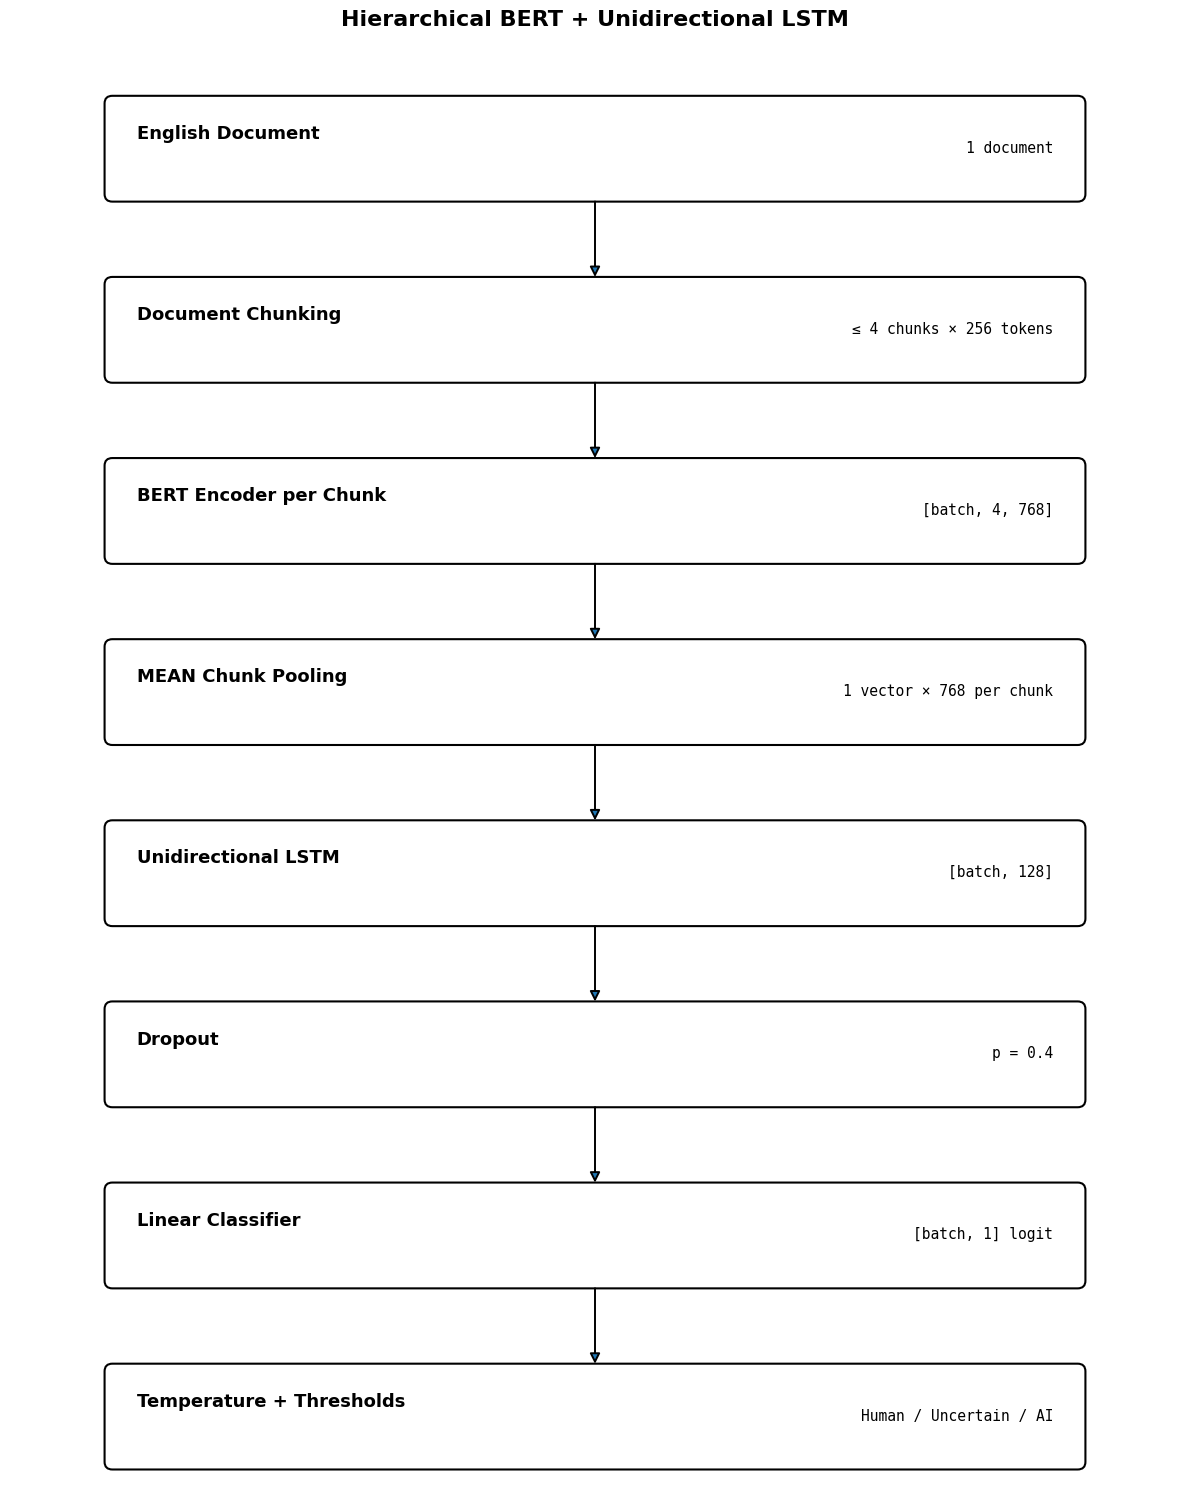

Diagram disimpan: /kaggle/working/bert_hierarchical_lstm_final/hierarchical_bert_lstm.png


In [20]:
from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch,
)


def draw_architecture():
    layers = [
        (
            "English Document",
            "1 document",
        ),
        (
            "Document Chunking",
            (
                f"≤ {MAX_CHUNKS} chunks "
                f"× {CHUNK_LENGTH} tokens"
            ),
        ),
        (
            "BERT Encoder per Chunk",
            (
                f"[batch, {MAX_CHUNKS}, "
                f"{model.encoder.hidden_size}]"
            ),
        ),
        (
            (
                f"{CHUNK_POOLING.upper()} "
                "Chunk Pooling"
            ),
            (
                f"1 vector × "
                f"{model.encoder.hidden_size} "
                "per chunk"
            ),
        ),
        (
            "Unidirectional LSTM",
            (
                f"[batch, "
                f"{LSTM_HIDDEN_SIZE}]"
            ),
        ),
        (
            "Dropout",
            f"p = {DROPOUT}",
        ),
        (
            "Linear Classifier",
            "[batch, 1] logit",
        ),
        (
            "Temperature + Thresholds",
            "Human / Uncertain / AI",
        ),
    ]

    figure_height = (
        len(layers) * 1.9
    )

    fig, ax = plt.subplots(
        figsize=(12, figure_height)
    )

    ax.set_xlim(0, 12)
    ax.set_ylim(0, figure_height)
    ax.axis("off")

    box_x = 1.0
    box_width = 10.0
    box_height = 1.05

    y_positions = []

    for index, (
        layer_name,
        shape,
    ) in enumerate(layers):
        y_position = (
            figure_height
            - 1.55
            - index * 1.9
        )

        y_positions.append(
            y_position
        )

        box = FancyBboxPatch(
            (
                box_x,
                y_position,
            ),
            box_width,
            box_height,
            boxstyle=(
                "round,pad=0.03,"
                "rounding_size=0.08"
            ),
            linewidth=1.5,
            fill=False,
        )

        ax.add_patch(box)

        ax.text(
            box_x + 0.3,
            y_position + 0.68,
            layer_name,
            fontsize=13,
            fontweight="bold",
            va="center",
        )

        ax.text(
            box_x + box_width - 0.3,
            y_position + 0.53,
            shape,
            fontsize=10.5,
            family="monospace",
            ha="right",
            va="center",
        )

    for current_y, next_y in zip(
        y_positions[:-1],
        y_positions[1:],
    ):
        arrow = FancyArrowPatch(
            (
                box_x + box_width / 2,
                current_y,
            ),
            (
                box_x + box_width / 2,
                next_y + box_height,
            ),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.4,
        )

        ax.add_patch(arrow)

    ax.set_title(
        (
            "Hierarchical BERT + "
            "Unidirectional LSTM"
        ),
        fontsize=16,
        fontweight="bold",
        pad=18,
    )

    diagram_path = (
        OUTPUT_DIR
        / "hierarchical_bert_lstm.png"
    )

    plt.tight_layout()
    plt.savefig(
        diagram_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

    print(
        "Diagram disimpan:",
        diagram_path,
    )


draw_architecture()

# 12. Loss, optimizer, scheduler, dan AMP

In [21]:
negative_count = int(
    (train_df["label"] == 0).sum()
)

positive_count = int(
    (train_df["label"] == 1).sum()
)

if BALANCE_STRATEGY == "class_weight":
    pos_weight_value = (
        negative_count
        / max(positive_count, 1)
    )
else:
    pos_weight_value = 1.0

pos_weight = torch.tensor(
    [pos_weight_value],
    dtype=torch.float32,
    device=DEVICE,
)

criterion = (
    nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )
)

optimizer = torch.optim.AdamW(
    [
        {
            "params": (
                model.bert.parameters()
            ),
            "lr": LEARNING_RATE_BERT,
        },
        {
            "params": chain(
                model.lstm.parameters(),
                model.classifier.parameters(),
            ),
            "lr": LEARNING_RATE_HEAD,
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

updates_per_epoch = math.ceil(
    len(train_loader)
    / GRADIENT_ACCUMULATION_STEPS
)

total_training_steps = (
    updates_per_epoch * EPOCHS
)

warmup_steps = int(
    WARMUP_RATIO
    * total_training_steps
)

scheduler = (
    get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=(
            warmup_steps
        ),
        num_training_steps=(
            total_training_steps
        ),
    )
)

try:
    scaler = (
        torch.amp.GradScaler(
            "cuda",
            enabled=AMP_ENABLED,
        )
    )
except TypeError:
    scaler = (
        torch.cuda.amp.GradScaler(
            enabled=AMP_ENABLED,
        )
    )

print(
    "Human train      :",
    negative_count,
)
print(
    "AI train         :",
    positive_count,
)
print(
    "Positive weight  :",
    pos_weight_value,
)
print(
    "Optimizer steps  :",
    total_training_steps,
)
print(
    "AMP              :",
    AMP_ENABLED,
)

Human train      : 20434
AI train         : 13398
Positive weight  : 1.5251530079116287
Optimizer steps  : 42290
AMP              : True


# 13. Training dan evaluation utilities

In [22]:
def set_bert_trainable(
    model,
    trainable,
):
    for parameter in model.bert.parameters():
        parameter.requires_grad = trainable


def sigmoid_numpy(logits):
    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    logits = np.clip(
        logits,
        -50,
        50,
    )

    return 1.0 / (1.0 + np.exp(-logits))


def calculate_binary_metrics(
    labels,
    probabilities,
    threshold=0.5,
):
    labels = np.asarray(
        labels,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="binary",
            zero_division=0,
        )
    )

    result = {
        "accuracy": accuracy_score(
            labels,
            predictions,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

    if len(np.unique(labels)) == 2:
        result["roc_auc"] = roc_auc_score(
            labels,
            probabilities,
        )
    else:
        result["roc_auc"] = np.nan

    return result, predictions


@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    criterion,
):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_logits = []

    for batch in tqdm(
        data_loader,
        desc="Evaluating",
        leave=False,
    ):
        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        chunk_mask = batch[
            "chunk_mask"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        linguistic_features = batch[
            "linguistic_features"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch[
            "labels"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                chunk_mask=chunk_mask,
                linguistic_features=linguistic_features,
            )

            loss = criterion(
                logits,
                labels,
            )

        total_loss += (
            loss.item()
            * labels.size(0)
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

        all_logits.extend(
            logits.detach()
            .cpu()
            .numpy()
        )

    labels_array = np.asarray(
        all_labels,
        dtype=int,
    )

    logits_array = np.asarray(
        all_logits,
        dtype=float,
    )

    probabilities = sigmoid_numpy(
        logits_array
    )

    metrics, predictions = (
        calculate_binary_metrics(
            labels_array,
            probabilities,
            threshold=0.5,
        )
    )

    return {
        "loss": (
            total_loss
            / len(data_loader.dataset)
        ),
        "labels": labels_array,
        "logits": logits_array,
        "probabilities": probabilities,
        "predictions": predictions,
        **metrics,
    }


def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    scheduler,
):
    model.train()

    total_loss = 0.0

    optimizer.zero_grad(
        set_to_none=True
    )

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False,
    )

    for step, batch in enumerate(
        progress_bar,
        start=1,
    ):
        input_ids = batch[
            "input_ids"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        attention_mask = batch[
            "attention_mask"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        chunk_mask = batch[
            "chunk_mask"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        linguistic_features = batch[
            "linguistic_features"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        labels = batch[
            "labels"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=AMP_ENABLED,
        ):
            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                chunk_mask=chunk_mask,
                linguistic_features=linguistic_features,
            )

            loss = criterion(
                logits,
                labels,
            )

            scaled_loss = (
                loss
                / GRADIENT_ACCUMULATION_STEPS
            )

        scaler.scale(
            scaled_loss
        ).backward()

        should_update = (
            step
            % GRADIENT_ACCUMULATION_STEPS
            == 0
            or step == len(data_loader)
        )

        if should_update:
            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                MAX_GRAD_NORM,
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            optimizer.zero_grad(
                set_to_none=True
            )

            scheduler.step()

        total_loss += (
            loss.item()
            * labels.size(0)
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss
        / len(data_loader.dataset)
    )

# 14. Training dengan checkpoint yang benar

In [23]:
best_model_path = (
    OUTPUT_DIR
    / "hierarchical_bert_lstm_best.pt"
)

history = []

best_validation_f1 = -np.inf
best_validation_loss = np.inf
best_epoch = None
epochs_without_improvement = 0

for epoch in range(
    1,
    EPOCHS + 1,
):
    bert_trainable = (
        epoch > FREEZE_BERT_EPOCHS
    )

    set_bert_trainable(
        model,
        bert_trainable,
    )

    print("=" * 80)
    print(f"Epoch {epoch}/{EPOCHS}")
    print("BERT trainable:", bert_trainable)

    training_loss = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
    )

    validation_result = evaluate_model(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
    )

    current_f1 = validation_result["f1"]
    current_loss = validation_result["loss"]

    epoch_record = {
        "epoch": epoch,
        "train_loss": training_loss,
        "val_loss": current_loss,
        "val_accuracy": validation_result["accuracy"],
        "val_precision": validation_result["precision"],
        "val_recall": validation_result["recall"],
        "val_f1": current_f1,
        "val_roc_auc": validation_result["roc_auc"],
    }

    history.append(epoch_record)

    print(
        f"Train loss: {training_loss:.4f} | "
        f"Val loss: {current_loss:.4f}"
    )

    print(
        f"Accuracy: {validation_result['accuracy']:.4f} | "
        f"Precision: {validation_result['precision']:.4f} | "
        f"Recall: {validation_result['recall']:.4f} | "
        f"F1: {current_f1:.4f} | "
        f"ROC-AUC: {validation_result['roc_auc']:.4f}"
    )

    f1_improved = (
        current_f1
        > best_validation_f1
        + MIN_IMPROVEMENT
    )

    f1_tied_loss_better = (
        abs(
            current_f1
            - best_validation_f1
        )
        <= MIN_IMPROVEMENT
        and current_loss
        < best_validation_loss
    )

    if f1_improved or f1_tied_loss_better:
        best_validation_f1 = current_f1
        best_validation_loss = current_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "model_name": MODEL_NAME,
                "chunk_length": CHUNK_LENGTH,
                "chunk_stride": CHUNK_STRIDE,
                "max_chunks": MAX_CHUNKS,
                "chunk_pooling": CHUNK_POOLING,
                "lstm_hidden_size": LSTM_HIDDEN_SIZE,
                "lstm_num_layers": LSTM_NUM_LAYERS,
                "dropout": DROPOUT,
                "linguistic_feature_dim": LINGUISTIC_FEATURE_DIM,
                "linguistic_mean": linguistic_mean,
                "linguistic_std": linguistic_std,
                "best_epoch": best_epoch,
                "best_validation_f1": best_validation_f1,
                "best_validation_loss": best_validation_loss,
            },
            best_model_path,
        )

        print("Checkpoint terbaik disimpan.")

    else:
        epochs_without_improvement += 1

        print(
            "Tidak meningkat:",
            f"{epochs_without_improvement}/{PATIENCE}",
        )

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping dijalankan.")
            break

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Best epoch          :", best_epoch)
print("Best validation F1  :", best_validation_f1)
print("Best validation loss:", best_validation_loss)

Epoch 1/10
BERT trainable: False


Training:   0%|          | 0/16916 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3387 [00:00<?, ?it/s]

Train loss: 0.3608 | Val loss: 0.2728
Accuracy: 0.9178 | Precision: 0.8324 | Recall: 0.9918 | F1: 0.9052 | ROC-AUC: 0.9869
Checkpoint terbaik disimpan.
Epoch 2/10
BERT trainable: True


Training:   0%|          | 0/16916 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/3387 [00:00<?, ?it/s]

Train loss: 0.0043 | Val loss: 0.0250
Accuracy: 0.9966 | Precision: 0.9926 | Recall: 0.9989 | F1: 0.9957 | ROC-AUC: 0.9997
Tidak meningkat: 1/2
Epoch 7/10
BERT trainable: True


Training:   0%|          | 0/16916 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3387 [00:00<?, ?it/s]

Train loss: 0.0010 | Val loss: 0.0261
Accuracy: 0.9970 | Precision: 0.9941 | Recall: 0.9985 | F1: 0.9963 | ROC-AUC: 0.9996
Tidak meningkat: 2/2
Early stopping dijalankan.
Best epoch          : 5
Best validation F1  : 0.9968289498227942
Best validation loss: 0.022612080512459318


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.360771,0.272832,0.917774,0.832446,0.991791,0.905159,0.986908
1,2,0.063122,0.034487,0.994538,0.994019,0.992164,0.993091,0.998964
2,3,0.022067,0.056555,0.988781,0.974144,0.998134,0.985993,0.999361
3,4,0.010386,0.034827,0.995424,0.991101,0.997388,0.994235,0.999290
4,5,0.005740,0.022612,0.997490,0.996643,0.997015,0.996829,0.999517
5,6,0.004251,0.025049,0.996605,0.992584,0.998881,0.995723,0.999705
6,7,0.001007,0.026133,0.997048,0.994056,0.998507,0.996277,0.999599


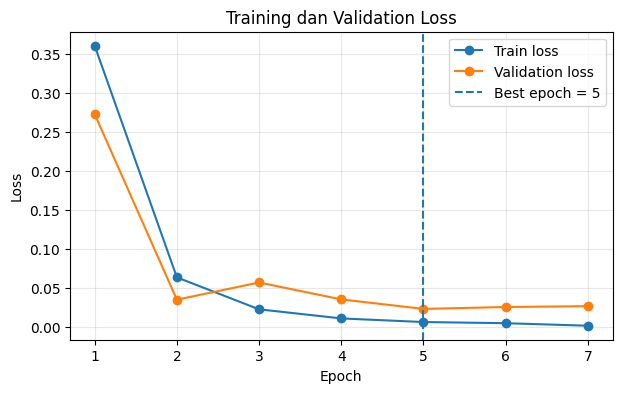

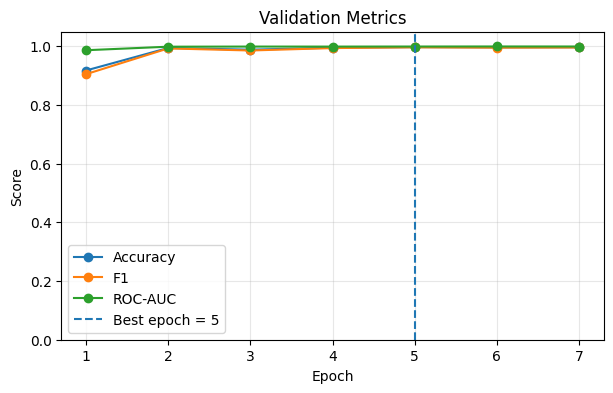

In [24]:
history_df = pd.DataFrame(
    history
)

display(history_df)

plt.figure(figsize=(7, 4))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation loss",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}",
)

plt.title(
    "Training dan Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    label="Accuracy",
)

plt.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    label="F1",
)

plt.plot(
    history_df["epoch"],
    history_df["val_roc_auc"],
    marker="o",
    label="ROC-AUC",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}",
)

plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 15. Muat checkpoint terbaik

In [25]:
checkpoint = torch.load(
    best_model_path,
    map_location=DEVICE,
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()

print(
    "Checkpoint dimuat dari epoch:",
    checkpoint["best_epoch"],
)

Checkpoint dimuat dari epoch: 5


# 16. Document-level temperature scaling

In [26]:
class TemperatureScaler(
    nn.Module
):
    def __init__(self):
        super().__init__()

        self.log_temperature = (
            nn.Parameter(
                torch.zeros(1)
            )
        )

    @property
    def temperature(self):
        return torch.exp(
            self.log_temperature
        )

    def forward(self, logits):
        return (
            logits
            / self.temperature
        )


def fit_temperature(
    validation_logits,
    validation_labels,
):
    temperature_model = (
        TemperatureScaler()
        .to(DEVICE)
    )

    logits_tensor = torch.tensor(
        validation_logits,
        dtype=torch.float32,
        device=DEVICE,
    )

    labels_tensor = torch.tensor(
        validation_labels,
        dtype=torch.float32,
        device=DEVICE,
    )

    calibration_loss = (
        nn.BCEWithLogitsLoss()
    )

    temperature_optimizer = (
        torch.optim.LBFGS(
            temperature_model.parameters(),
            lr=0.05,
            max_iter=50,
        )
    )

    def closure():
        temperature_optimizer.zero_grad()

        scaled_logits = (
            temperature_model(
                logits_tensor
            )
        )

        loss = calibration_loss(
            scaled_logits,
            labels_tensor,
        )

        loss.backward()

        return loss

    temperature_optimizer.step(
        closure
    )

    return float(
        temperature_model
        .temperature
        .detach()
        .cpu()
        .item()
    )


validation_result = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
)

validation_probabilities_before = (
    sigmoid_numpy(
        validation_result["logits"]
    )
)

if USE_TEMPERATURE_SCALING:
    fitted_temperature = (
        fit_temperature(
            validation_result["logits"],
            validation_result["labels"],
        )
    )
else:
    fitted_temperature = 1.0


def calibrated_probabilities(
    logits,
    temperature,
):
    return sigmoid_numpy(
        np.asarray(logits)
        / max(
            float(temperature),
            1e-6,
        )
    )


validation_probabilities_after = (
    calibrated_probabilities(
        validation_result["logits"],
        fitted_temperature,
    )
)

validation_nll_before = log_loss(
    validation_result["labels"],
    validation_probabilities_before,
    labels=[0, 1],
)

validation_nll_after = log_loss(
    validation_result["labels"],
    validation_probabilities_after,
    labels=[0, 1],
)

validation_brier_before = (
    brier_score_loss(
        validation_result["labels"],
        validation_probabilities_before,
    )
)

validation_brier_after = (
    brier_score_loss(
        validation_result["labels"],
        validation_probabilities_after,
    )
)

# Temperature scaling diaktifkan hanya jika validation NLL membaik.
if (
    USE_TEMPERATURE_SCALING
    and validation_nll_after
    < validation_nll_before
):
    TEMPERATURE = fitted_temperature
else:
    TEMPERATURE = 1.0

print(
    "Fitted temperature:",
    fitted_temperature,
)
print(
    "Temperature used  :",
    TEMPERATURE,
)
print(
    "Validation NLL before:",
    validation_nll_before,
)
print(
    "Validation NLL after :",
    validation_nll_after,
)
print(
    "Validation Brier before:",
    validation_brier_before,
)
print(
    "Validation Brier after :",
    validation_brier_after,
)

validation_calibrated_probabilities = (
    calibrated_probabilities(
        validation_result["logits"],
        TEMPERATURE,
    )
)

Evaluating:   0%|          | 0/3387 [00:00<?, ?it/s]

Fitted temperature: 1.6797796487808228
Temperature used  : 1.6797796487808228
Validation NLL before: 0.017438371519211508
Validation NLL after : 0.01218700319435653
Validation Brier before: 0.0024031379598059067
Validation Brier after : 0.00231193752432977


# 17. Validation-derived Human dan AI thresholds

In [27]:
def select_ai_threshold(
    labels,
    probabilities,
    target_fpr=0.01,
):
    rows = []

    for threshold in np.arange(
        0.01,
        1.00,
        0.005,
    ):
        predictions = (
            probabilities >= threshold
        ).astype(int)

        tn, fp, fn, tp = (
            confusion_matrix(
                labels,
                predictions,
                labels=[0, 1],
            ).ravel()
        )

        fpr = (
            fp / max(fp + tn, 1)
        )

        recall = (
            tp / max(tp + fn, 1)
        )

        rows.append(
            {
                "threshold": threshold,
                "fpr": fpr,
                "recall": recall,
            }
        )

    table = pd.DataFrame(rows)

    eligible = table[
        table["fpr"] <= target_fpr
    ].copy()

    if eligible.empty:
        selected = (
            table.sort_values(
                ["fpr", "recall"],
                ascending=[True, False],
            )
            .iloc[0]
        )
    else:
        # Threshold terendah dengan FPR aman
        # memberi recall AI tertinggi.
        selected = (
            eligible.sort_values(
                ["recall", "threshold"],
                ascending=[False, True],
            )
            .iloc[0]
        )

    return (
        float(
            selected["threshold"]
        ),
        table,
    )


def select_human_threshold(
    labels,
    probabilities,
    target_fnr=0.01,
):
    rows = []

    for threshold in np.arange(
        0.00,
        0.99,
        0.005,
    ):
        # p <= threshold dianggap confidently Human.
        ai_mask = labels == 1

        false_human_on_ai = np.sum(
            ai_mask
            & (
                probabilities
                <= threshold
            )
        )

        total_ai = np.sum(ai_mask)

        fnr = (
            false_human_on_ai
            / max(total_ai, 1)
        )

        human_coverage = np.mean(
            probabilities <= threshold
        )

        rows.append(
            {
                "threshold": threshold,
                "fnr": fnr,
                "human_coverage": (
                    human_coverage
                ),
            }
        )

    table = pd.DataFrame(rows)

    eligible = table[
        table["fnr"] <= target_fnr
    ].copy()

    if eligible.empty:
        selected = (
            table.sort_values(
                ["fnr", "human_coverage"],
                ascending=[True, False],
            )
            .iloc[0]
        )
    else:
        # Threshold tertinggi dengan FNR aman
        # memberi cakupan Human terbesar.
        selected = (
            eligible.sort_values(
                ["human_coverage", "threshold"],
                ascending=[False, False],
            )
            .iloc[0]
        )

    return (
        float(
            selected["threshold"]
        ),
        table,
    )


THRESHOLD_AI, ai_threshold_table = (
    select_ai_threshold(
        labels=validation_result[
            "labels"
        ],
        probabilities=(
            validation_calibrated_probabilities
        ),
        target_fpr=(
            TARGET_AI_FALSE_POSITIVE_RATE
        ),
    )
)

THRESHOLD_HUMAN, human_threshold_table = (
    select_human_threshold(
        labels=validation_result[
            "labels"
        ],
        probabilities=(
            validation_calibrated_probabilities
        ),
        target_fnr=(
            TARGET_HUMAN_FALSE_NEGATIVE_RATE
        ),
    )
)

# Pastikan zona Uncertain tidak negatif.
if THRESHOLD_HUMAN >= THRESHOLD_AI:
    midpoint = (
        THRESHOLD_HUMAN
        + THRESHOLD_AI
    ) / 2.0

    THRESHOLD_HUMAN = min(
        THRESHOLD_HUMAN,
        midpoint - 0.01,
    )

    THRESHOLD_AI = max(
        THRESHOLD_AI,
        midpoint + 0.01,
    )

# Tambahan margin keamanan: dorong threshold AI sedikit lebih tinggi dan
# threshold Human sedikit lebih rendah, supaya kasus borderline (probabilitas
# hanya beda tipis dari threshold) otomatis jatuh ke zona "Uncertain"
# alih-alih dipaksa menjadi keputusan AI/Human yang terlalu percaya diri.
THRESHOLD_AI = min(THRESHOLD_AI + THRESHOLD_SAFETY_MARGIN, 0.995)
THRESHOLD_HUMAN = max(THRESHOLD_HUMAN - THRESHOLD_SAFETY_MARGIN, 0.005)

print(
    "Human threshold:",
    THRESHOLD_HUMAN,
)
print(
    "AI threshold   :",
    THRESHOLD_AI,
)
print(
    "Uncertain zone :",
    (
        THRESHOLD_HUMAN,
        THRESHOLD_AI,
    ),
)

Human threshold: 0.4775
AI threshold   : 0.5175
Uncertain zone : (0.4775, 0.5175)


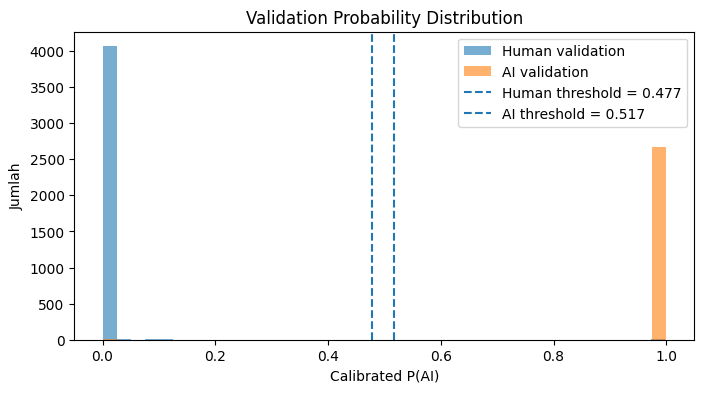

In [28]:
plt.figure(figsize=(8, 4))

human_probabilities = (
    validation_calibrated_probabilities[
        validation_result["labels"] == 0
    ]
)

ai_probabilities = (
    validation_calibrated_probabilities[
        validation_result["labels"] == 1
    ]
)

plt.hist(
    human_probabilities,
    bins=40,
    alpha=0.6,
    label="Human validation",
)

plt.hist(
    ai_probabilities,
    bins=40,
    alpha=0.6,
    label="AI validation",
)

plt.axvline(
    THRESHOLD_HUMAN,
    linestyle="--",
    label=(
        f"Human threshold = "
        f"{THRESHOLD_HUMAN:.3f}"
    ),
)

plt.axvline(
    THRESHOLD_AI,
    linestyle="--",
    label=(
        f"AI threshold = "
        f"{THRESHOLD_AI:.3f}"
    ),
)

plt.xlabel("Calibrated P(AI)")
plt.ylabel("Jumlah")
plt.title(
    "Validation Probability Distribution"
)
plt.legend()
plt.show()

# 18. Final test evaluation

In [29]:
test_result = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
)

test_probabilities = (
    calibrated_probabilities(
        test_result["logits"],
        TEMPERATURE,
    )
)

# Binary metrics memakai AI threshold.
test_binary_metrics, (
    test_binary_predictions
) = calculate_binary_metrics(
    labels=test_result["labels"],
    probabilities=test_probabilities,
    threshold=THRESHOLD_AI,
)

print("BINARY TEST RESULT")
print("-" * 60)

for metric_name in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]:
    print(
        f"{metric_name:>10}: "
        f"{test_binary_metrics[metric_name]:.4f}"
    )

print(
    f"{'loss':>10}: "
    f"{test_result['loss']:.4f}"
)
print(
    f"{'threshold':>10}: "
    f"{THRESHOLD_AI:.4f}"
)
print(
    f"{'temperature':>10}: "
    f"{TEMPERATURE:.4f}"
)

print("\nClassification report:")
print(
    classification_report(
        test_result["labels"],
        test_binary_predictions,
        target_names=[
            "Human",
            "AI",
        ],
        digits=4,
        zero_division=0,
    )
)

Evaluating:   0%|          | 0/3386 [00:00<?, ?it/s]

BINARY TEST RESULT
------------------------------------------------------------
  accuracy: 0.9960
 precision: 0.9966
    recall: 0.9933
        f1: 0.9950
   roc_auc: 0.9996
      loss: 0.0365
 threshold: 0.5175
temperature: 1.6798

Classification report:
              precision    recall  f1-score   support

       Human     0.9956    0.9978    0.9967      4092
          AI     0.9966    0.9933    0.9950      2679

    accuracy                         0.9960      6771
   macro avg     0.9961    0.9955    0.9958      6771
weighted avg     0.9960    0.9960    0.9960      6771



In [30]:
def three_way_decisions(
    probabilities,
    threshold_human,
    threshold_ai,
):
    decisions = np.full(
        len(probabilities),
        "Uncertain",
        dtype=object,
    )

    decisions[
        probabilities
        <= threshold_human
    ] = "Human"

    decisions[
        probabilities
        >= threshold_ai
    ] = "AI"

    return decisions


test_decisions = three_way_decisions(
    probabilities=test_probabilities,
    threshold_human=(
        THRESHOLD_HUMAN
    ),
    threshold_ai=THRESHOLD_AI,
)

confident_mask = (
    test_decisions != "Uncertain"
)

confident_predictions = np.where(
    test_decisions == "AI",
    1,
    0,
)

coverage = np.mean(
    confident_mask
)

selective_accuracy = (
    accuracy_score(
        test_result["labels"][
            confident_mask
        ],
        confident_predictions[
            confident_mask
        ],
    )
    if confident_mask.any()
    else np.nan
)

uncertain_rate = 1.0 - coverage

print("THREE-WAY TEST RESULT")
print("-" * 60)
print(
    "Coverage            :",
    round(float(coverage), 4),
)
print(
    "Uncertain rate      :",
    round(float(uncertain_rate), 4),
)
print(
    "Selective accuracy  :",
    round(
        float(selective_accuracy),
        4,
    ),
)
print(
    "Human decisions     :",
    int(
        np.sum(
            test_decisions == "Human"
        )
    ),
)
print(
    "Uncertain decisions :",
    int(
        np.sum(
            test_decisions
            == "Uncertain"
        )
    ),
)
print(
    "AI decisions        :",
    int(
        np.sum(
            test_decisions == "AI"
        )
    ),
)

THREE-WAY TEST RESULT
------------------------------------------------------------
Coverage            : 1.0
Uncertain rate      : 0.0
Selective accuracy  : 0.996
Human decisions     : 4101
Uncertain decisions : 0
AI decisions        : 2670


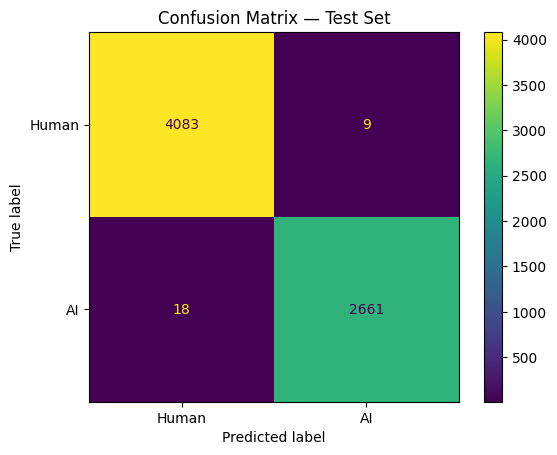

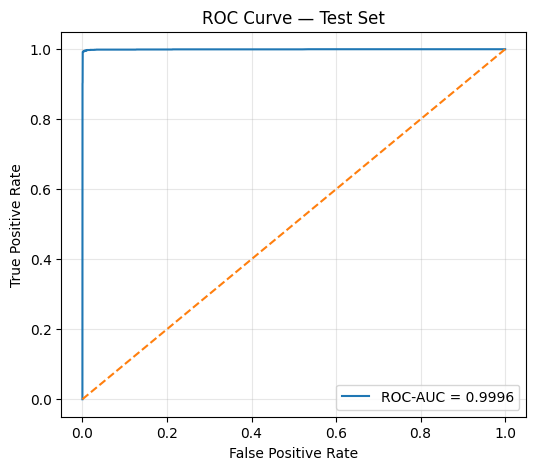

In [31]:
confusion = confusion_matrix(
    test_result["labels"],
    test_binary_predictions,
)

display_confusion = (
    ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=[
            "Human",
            "AI",
        ],
    )
)

display_confusion.plot(
    values_format="d"
)

plt.title(
    "Confusion Matrix — Test Set"
)
plt.show()

fpr, tpr, _ = roc_curve(
    test_result["labels"],
    test_probabilities,
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=(
        f"ROC-AUC = "
        f"{test_binary_metrics['roc_auc']:.4f}"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel(
    "False Positive Rate"
)
plt.ylabel(
    "True Positive Rate"
)
plt.title(
    "ROC Curve — Test Set"
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 19. Calibration evaluation

Test NLL before  : 0.026294112653479418
Test NLL after   : 0.01733751819840392
Test Brier before: 0.003774125785509439
Test Brier after : 0.0035606308659198956


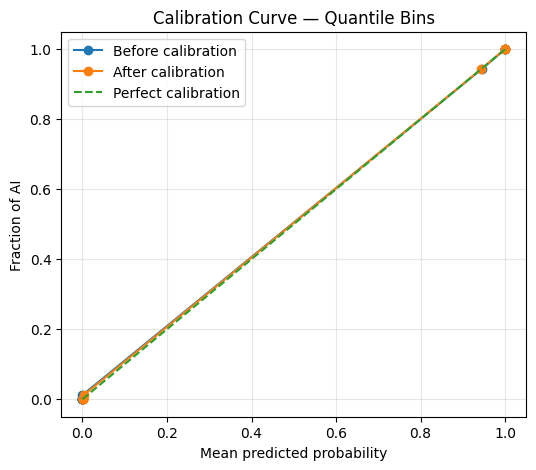

In [32]:
test_probabilities_before = (
    sigmoid_numpy(
        test_result["logits"]
    )
)

test_nll_before = log_loss(
    test_result["labels"],
    test_probabilities_before,
    labels=[0, 1],
)

test_nll_after = log_loss(
    test_result["labels"],
    test_probabilities,
    labels=[0, 1],
)

test_brier_before = (
    brier_score_loss(
        test_result["labels"],
        test_probabilities_before,
    )
)

test_brier_after = (
    brier_score_loss(
        test_result["labels"],
        test_probabilities,
    )
)

print(
    "Test NLL before  :",
    test_nll_before,
)
print(
    "Test NLL after   :",
    test_nll_after,
)
print(
    "Test Brier before:",
    test_brier_before,
)
print(
    "Test Brier after :",
    test_brier_after,
)

fraction_positive_before, (
    mean_predicted_before
) = calibration_curve(
    test_result["labels"],
    test_probabilities_before,
    n_bins=10,
    strategy="quantile",
)

fraction_positive_after, (
    mean_predicted_after
) = calibration_curve(
    test_result["labels"],
    test_probabilities,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 5))

plt.plot(
    mean_predicted_before,
    fraction_positive_before,
    marker="o",
    label="Before calibration",
)

plt.plot(
    mean_predicted_after,
    fraction_positive_after,
    marker="o",
    label="After calibration",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel(
    "Mean predicted probability"
)
plt.ylabel(
    "Fraction of AI"
)
plt.title(
    "Calibration Curve — Quantile Bins"
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 20. Error analysis

In [33]:
test_analysis = (
    test_df.copy()
)

test_analysis[
    "probability_ai"
] = test_probabilities

test_analysis[
    "binary_prediction"
] = test_binary_predictions

test_analysis[
    "decision"
] = test_decisions

test_analysis[
    "total_chunks"
] = test_encoded[
    "total_chunks"
]

false_positives = (
    test_analysis[
        (
            test_analysis["label"] == 0
        )
        & (
            test_analysis[
                "binary_prediction"
            ] == 1
        )
    ]
    .sort_values(
        "probability_ai",
        ascending=False,
    )
)

false_negatives = (
    test_analysis[
        (
            test_analysis["label"] == 1
        )
        & (
            test_analysis[
                "binary_prediction"
            ] == 0
        )
    ]
    .sort_values(
        "probability_ai",
        ascending=True,
    )
)

print(
    "False positive Human → AI:",
    len(false_positives),
)
print(
    "False negative AI → Human:",
    len(false_negatives),
)

display(
    false_positives[
        [
            "word_count",
            "total_chunks",
            "probability_ai",
            "decision",
            "model_text",
        ]
    ].head(10)
)

display(
    false_negatives[
        [
            "word_count",
            "total_chunks",
            "probability_ai",
            "decision",
            "model_text",
        ]
    ].head(10)
)

False positive Human → AI: 9
False negative AI → Human: 18


,word_count,total_chunks,probability_ai,decision,model_text
911,488,3,0.998459,AI,Generic_Name\n\nGeneric_Name\n\nEnglish 8 Hono...
532,486,3,0.997273,AI,It should come as no surprise that the secret ...
6141,396,3,0.990964,AI,It seems that almost everyone I know has a car...
3456,478,3,0.961522,AI,There are a plethora of ways to gain education...
2179,304,2,0.855138,AI,"Dear Principal,\n\nI think that this new polic..."
6422,272,2,0.817215,AI,This manual is a guide for analyzing the econo...
6455,216,2,0.768720,AI,"In the modern era, many terms related to artif..."
1107,279,2,0.754365,AI,Participating in extracurricular activity like...
3072,221,1,0.634803,AI,"Dear Principal,\n\nThe first policy would be b..."


,word_count,total_chunks,probability_ai,decision,model_text
5563,325,2,0.000907,Human,"Intro:\nThe authur of ""The Challenge of Explor..."
4344,379,3,0.001471,Human,"Dear Mr. Smith,\n\nI am writting to you today ..."
5362,345,2,0.002790,Human,"Hi, my name is Jill and I am a scietist at NAS..."
4468,214,1,0.003825,Human,Dear Principal\n\nI believe that students shou...
5969,187,1,0.004043,Human,Many people believe that the Face on Mars was ...
4788,285,2,0.005513,Human,I think student should have the rite to grade ...
4709,239,2,0.008433,Human,Disneyland is the place I would love to explor...
4310,423,3,0.008669,Human,The use of cellphones in the classroom is a to...
5528,412,3,0.009057,Human,"In the future, I hope that one day I will beco..."
5381,415,3,0.009162,Human,Technology is the bridge that connects people ...


# 21. Optional BERT mean-pooling baseline

Baseline ini memakai chunk vectors yang sama, tetapi tidak memakai LSTM:

```text
BERT chunk vectors
↓
Masked mean antar-chunk
↓
Linear classifier
```

Aktifkan:

```python
RUN_BERT_MEAN_BASELINE = True
```

Perbandingan yang adil:

- preprocessing sama;
- split sama;
- chunking sama;
- BERT sama;
- perbedaan utama hanya LSTM versus mean pooling.

Jika BERT + LSTM tidak mengalahkan baseline secara konsisten, kontribusi LSTM belum terbukti.

In [34]:
class HierarchicalBertMeanClassifier(
    nn.Module
):
    def __init__(
        self,
        model_name,
        dropout=0.40,
        chunk_pooling="mean",
        gradient_checkpointing=True,
    ):
        super().__init__()

        self.encoder = (
            HierarchicalBertEncoder(
                model_name=model_name,
                pooling=chunk_pooling,
                gradient_checkpointing=(
                    gradient_checkpointing
                ),
            )
        )

        self.bert = (
            self.encoder.bert
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            self.encoder.hidden_size,
            1,
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        chunk_mask,
        linguistic_features=None,
    ):
        chunk_vectors = (
            self.encoder.encode_chunks(
                input_ids=input_ids,
                attention_mask=(
                    attention_mask
                ),
                chunk_mask=chunk_mask,
            )
        )

        chunk_mask_float = (
            chunk_mask
            .unsqueeze(-1)
            .to(
                chunk_vectors.dtype
            )
        )

        document_vector = (
            (
                chunk_vectors
                * chunk_mask_float
            ).sum(dim=1)
            / chunk_mask_float.sum(
                dim=1
            ).clamp(min=1.0)
        )

        return self.classifier(
            self.dropout(
                document_vector
            )
        ).squeeze(-1)


if RUN_BERT_MEAN_BASELINE:
    print(
        "Baseline class tersedia."
    )
    print(
        "Untuk eksperimen yang benar, "
        "buat instance baseline dan latih "
        "dengan fungsi training yang sama."
    )
else:
    print(
        "Baseline tidak dijalankan "
        "untuk menghemat waktu GPU."
    )

Baseline tidak dijalankan untuk menghemat waktu GPU.


# 22. Optional external test set

In [35]:
# External test paling kuat untuk menguji generalisasi.
#
# Format:
# text,label
#
# Contoh:
# EXTERNAL_TEST_PATH = "/content/external_test.csv"
EXTERNAL_TEST_PATH = None

if EXTERNAL_TEST_PATH is not None:
    external_df = load_dataset(
        EXTERNAL_TEST_PATH
    )

    external_df[
        "label"
    ] = external_df[
        "label"
    ].apply(normalize_label)

    external_df[
        "text_raw"
    ] = external_df[
        "text"
    ].fillna("").astype(str)

    external_df[
        "text_clean"
    ] = external_df[
        "text_raw"
    ].apply(minimal_clean_text)

    external_df = external_df[
        external_df[
            "label"
        ].isin([0, 1])
        & external_df[
            "text_clean"
        ].str.len().gt(0)
    ].copy()

    external_df[
        "label"
    ] = external_df[
        "label"
    ].astype(int)

    external_df[
        "model_text"
    ] = (
        external_df[
            "text_clean"
        ]
        if TEXT_MODE == "clean"
        else external_df[
            "text_raw"
        ]
    )

    external_encoded = (
        encode_documents(
            external_df[
                "model_text"
            ].tolist(),
            description=(
                "Encoding external test"
            ),
        )
    )

    external_dataset = (
        HierarchicalTextDataset(
            external_encoded,
            external_df[
                "label"
            ].values,
        )
    )

    external_loader = DataLoader(
        external_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    external_result = (
        evaluate_model(
            model=model,
            data_loader=(
                external_loader
            ),
            criterion=criterion,
        )
    )

    external_probabilities = (
        calibrated_probabilities(
            external_result["logits"],
            TEMPERATURE,
        )
    )

    external_metrics, _ = (
        calculate_binary_metrics(
            external_result["labels"],
            external_probabilities,
            threshold=THRESHOLD_AI,
        )
    )

    print(
        "External test metrics:"
    )
    print(external_metrics)
else:
    print(
        "External test tidak dijalankan."
    )

External test tidak dijalankan.


# 23. Simpan model, tokenizer, dan hasil

In [36]:
tokenizer_directory = (
    OUTPUT_DIR / "tokenizer"
)

tokenizer.save_pretrained(
    tokenizer_directory
)

experiment_config = {
    "model_name": MODEL_NAME,
    "architecture": (
        "Hierarchical BERT + "
        "unidirectional LSTM"
    ),
    "label_mapping": {
        "0": "Human",
        "1": "AI",
    },
    "text_mode": TEXT_MODE,
    "chunk_length": CHUNK_LENGTH,
    "chunk_stride": CHUNK_STRIDE,
    "max_chunks": MAX_CHUNKS,
    "chunk_pooling": CHUNK_POOLING,
    "lstm_hidden_size": (
        LSTM_HIDDEN_SIZE
    ),
    "lstm_num_layers": (
        LSTM_NUM_LAYERS
    ),
    "bidirectional": False,
    "dropout": DROPOUT,
    "balance_strategy": (
        BALANCE_STRATEGY
    ),
    "best_epoch": best_epoch,
    "best_validation_f1": (
        best_validation_f1
    ),
    "best_validation_loss": (
        best_validation_loss
    ),
    "temperature": TEMPERATURE,
    "threshold_human": (
        THRESHOLD_HUMAN
    ),
    "threshold_ai": THRESHOLD_AI,
    "target_ai_fpr": (
        TARGET_AI_FALSE_POSITIVE_RATE
    ),
    "target_human_fnr": (
        TARGET_HUMAN_FALSE_NEGATIVE_RATE
    ),
    "near_duplicate_grouping": (
        ENABLE_NEAR_DUPLICATE_GROUPING
    ),
    "seed": SEED,
    "linguistic_feature_dim": (
        LINGUISTIC_FEATURE_DIM
    ),
    "linguistic_stats_saved": True,
}

with open(
    OUTPUT_DIR
    / "experiment_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_config,
        file,
        indent=2,
        ensure_ascii=False,
    )

history_df.to_csv(
    OUTPUT_DIR
    / "training_history.csv",
    index=False,
)

test_analysis[
    [
        "text_hash",
        "label",
        "binary_prediction",
        "decision",
        "probability_ai",
        "word_count",
        "total_chunks",
    ]
].to_csv(
    OUTPUT_DIR
    / "test_predictions.csv",
    index=False,
)

metrics_to_save = {
    "test_loss": float(
        test_result["loss"]
    ),
    **{
        key: float(value)
        for key, value
        in test_binary_metrics.items()
    },
    "coverage": float(coverage),
    "uncertain_rate": float(
        uncertain_rate
    ),
    "selective_accuracy": float(
        selective_accuracy
    ),
    "test_nll_before": float(
        test_nll_before
    ),
    "test_nll_after": float(
        test_nll_after
    ),
    "test_brier_before": float(
        test_brier_before
    ),
    "test_brier_after": float(
        test_brier_after
    ),
}

with open(
    OUTPUT_DIR
    / "test_metrics.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metrics_to_save,
        file,
        indent=2,
    )

zip_path = shutil.make_archive(
    "/kaggle/working/"
    "hierarchical_bert_lstm_result",
    "zip",
    root_dir=OUTPUT_DIR,
)

print(
    "Model directory:",
    OUTPUT_DIR,
)
print(
    "ZIP result:",
    zip_path,
)

Model directory: /kaggle/working/bert_hierarchical_lstm_final
ZIP result: /kaggle/working/hierarchical_bert_lstm_result.zip


## 24. Catatan interpretasi

Hasil internal yang sangat tinggi belum otomatis berarti model mampu mendeteksi semua tulisan AI.

Lakukan:

1. `ENABLE_NEAR_DUPLICATE_GROUPING = True`.
2. Ulangi eksperimen dengan beberapa seed, misalnya `42`, `123`, dan `2026`.
3. Bandingkan dengan baseline tanpa LSTM.
4. Uji file eksternal yang tidak pernah dipakai saat pengembangan.
5. Analisis false positive Human → AI.
6. Laporkan `coverage` dan `selective accuracy` untuk keputusan tiga zona.

Output `AI` adalah indikasi pola yang mirip data AI, bukan bukti mutlak mengenai penulis teks.

# 25. K-Fold Cross-Validation (Opsional)

Bagian ini **tidak menggantikan** training utama di atas -- training utama tetap
memakai satu train/val/test split dan model hasilnya yang disimpan. Bagian ini
hanya untuk **memvalidasi seberapa stabil performa model** di beberapa
pembagian data yang berbeda, sesuai saran metodologis: melaporkan mean ± std
lintas fold jauh lebih meyakinkan di sidang daripada satu angka akurasi dari
satu split saja.

Catatan:
- CV dijalankan pada gabungan `train_df + val_df` (test set asli tetap disisihkan
  sebagai blind test, tidak ikut CV).
- Memakai `StratifiedGroupKFold` (bukan `StratifiedKFold` biasa) dengan
  `group_id` supaya dokumen dari grup near-duplicate yang sama tidak pernah
  terpisah antara fold train dan fold validasi -- konsisten dengan strategi
  anti-leakage yang sudah dipakai di split utama.
- `KFOLD_EPOCHS` sengaja dibuat lebih kecil dari `EPOCHS` utama supaya total
  waktu training (N_FOLDS x KFOLD_EPOCHS) tetap realistis. Set `RUN_KFOLD_CV = True`
  di sel KONFIGURASI untuk menjalankan, lalu jalankan sel ini.


In [37]:
from sklearn.model_selection import StratifiedGroupKFold


def run_single_fold(fold_index, train_fold_df, val_fold_df):
    print("=" * 80)
    print(f"FOLD {fold_index + 1}/{N_FOLDS}")
    print("=" * 80)
    print("Train:", len(train_fold_df), "| Val:", len(val_fold_df))

    # -- 1. Encode chunks BERT (reuse fungsi yang sudah ada, tanpa cache
    #       supaya tidak bentrok dengan cache dari split utama). --
    fold_train_encoded = encode_documents(
        train_fold_df["model_text"].tolist(),
        description=f"Fold {fold_index + 1} - encoding train",
    )
    fold_val_encoded = encode_documents(
        val_fold_df["model_text"].tolist(),
        description=f"Fold {fold_index + 1} - encoding val",
    )

    # -- 2. Fitur linguistik (stylometric + POS + perplexity/burstiness),
    #       distandardisasi memakai mean/std dari fold TRAIN saja. --
    fold_train_linguistic = build_linguistic_matrix(train_fold_df)
    fold_val_linguistic = build_linguistic_matrix(val_fold_df)

    fold_mean = fold_train_linguistic.mean(axis=0)
    fold_std = fold_train_linguistic.std(axis=0)
    fold_std[fold_std < 1e-6] = 1.0

    fold_train_linguistic = (fold_train_linguistic - fold_mean) / fold_std
    fold_val_linguistic = (fold_val_linguistic - fold_mean) / fold_std

    # -- 3. Dataset & DataLoader. --
    fold_train_dataset = HierarchicalTextDataset(
        fold_train_encoded, train_fold_df["label"].values, fold_train_linguistic
    )
    fold_val_dataset = HierarchicalTextDataset(
        fold_val_encoded, val_fold_df["label"].values, fold_val_linguistic
    )

    pin_memory = DEVICE.type == "cuda"

    fold_train_loader = DataLoader(
        fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )
    fold_val_loader = DataLoader(
        fold_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=pin_memory,
    )

    # -- 4. Model baru dari nol untuk fold ini (tidak boleh reuse weight
    #       dari fold sebelumnya / dari model utama, supaya evaluasi fair). --
    fold_model = HierarchicalBertLSTMClassifier(
        model_name=MODEL_NAME,
        lstm_hidden_size=LSTM_HIDDEN_SIZE,
        lstm_num_layers=LSTM_NUM_LAYERS,
        dropout=DROPOUT,
        chunk_pooling=CHUNK_POOLING,
        gradient_checkpointing=ENABLE_GRADIENT_CHECKPOINTING,
        linguistic_feature_dim=LINGUISTIC_FEATURE_DIM,
    ).to(DEVICE)

    fold_negative = int((train_fold_df["label"] == 0).sum())
    fold_positive = int((train_fold_df["label"] == 1).sum())
    fold_pos_weight_value = fold_negative / max(fold_positive, 1)

    fold_criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([fold_pos_weight_value], dtype=torch.float32, device=DEVICE)
    )

    fold_optimizer = torch.optim.AdamW(
        [
            {"params": fold_model.bert.parameters(), "lr": LEARNING_RATE_BERT},
            {"params": chain(fold_model.lstm.parameters(), fold_model.classifier.parameters()),
             "lr": LEARNING_RATE_HEAD},
        ],
        weight_decay=WEIGHT_DECAY,
    )

    fold_updates_per_epoch = math.ceil(len(fold_train_loader) / GRADIENT_ACCUMULATION_STEPS)
    fold_total_steps = fold_updates_per_epoch * KFOLD_EPOCHS
    fold_warmup_steps = int(WARMUP_RATIO * fold_total_steps)

    fold_scheduler = get_linear_schedule_with_warmup(
        fold_optimizer,
        num_warmup_steps=fold_warmup_steps,
        num_training_steps=fold_total_steps,
    )

    global scaler
    try:
        scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except TypeError:
        scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    # -- 5. Training singkat untuk fold ini. --
    for epoch in range(1, KFOLD_EPOCHS + 1):
        set_bert_trainable(fold_model, epoch > FREEZE_BERT_EPOCHS)

        train_one_epoch(
            model=fold_model,
            data_loader=fold_train_loader,
            criterion=fold_criterion,
            optimizer=fold_optimizer,
            scheduler=fold_scheduler,
        )

    # -- 6. Evaluasi fold ini. --
    fold_result = evaluate_model(
        model=fold_model,
        data_loader=fold_val_loader,
        criterion=fold_criterion,
    )

    print(
        f"Fold {fold_index + 1} -> "
        f"Acc: {fold_result['accuracy']:.4f} | "
        f"F1: {fold_result['f1']:.4f} | "
        f"ROC-AUC: {fold_result['roc_auc']:.4f}"
    )

    # Bersihkan memori GPU sebelum fold berikutnya.
    del fold_model, fold_optimizer, fold_scheduler
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "fold": fold_index + 1,
        "accuracy": fold_result["accuracy"],
        "precision": fold_result["precision"],
        "recall": fold_result["recall"],
        "f1": fold_result["f1"],
        "roc_auc": fold_result["roc_auc"],
    }


if RUN_KFOLD_CV:
    cv_source_df = pd.concat([train_df, val_df], ignore_index=True)

    if "group_id" in cv_source_df.columns:
        cv_groups = cv_source_df["group_id"]
    else:
        # Fallback: tiap dokumen jadi grupnya sendiri kalau near-duplicate
        # grouping tidak diaktifkan.
        cv_groups = np.arange(len(cv_source_df))

    kfold_splitter = StratifiedGroupKFold(
        n_splits=N_FOLDS, shuffle=True, random_state=SEED
    )

    fold_results = []

    for fold_index, (train_idx, val_idx) in enumerate(
        kfold_splitter.split(cv_source_df, y=cv_source_df["label"], groups=cv_groups)
    ):
        fold_train_df = cv_source_df.iloc[train_idx].reset_index(drop=True)
        fold_val_df = cv_source_df.iloc[val_idx].reset_index(drop=True)

        fold_results.append(run_single_fold(fold_index, fold_train_df, fold_val_df))

    kfold_results_df = pd.DataFrame(fold_results)

    print("=" * 80)
    print("RINGKASAN K-FOLD CROSS-VALIDATION")
    print("=" * 80)
    display(kfold_results_df)

    summary_row = {
        "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
        "mean": [
            kfold_results_df["accuracy"].mean(),
            kfold_results_df["precision"].mean(),
            kfold_results_df["recall"].mean(),
            kfold_results_df["f1"].mean(),
            kfold_results_df["roc_auc"].mean(),
        ],
        "std": [
            kfold_results_df["accuracy"].std(),
            kfold_results_df["precision"].std(),
            kfold_results_df["recall"].std(),
            kfold_results_df["f1"].std(),
            kfold_results_df["roc_auc"].std(),
        ],
    }

    display(pd.DataFrame(summary_row))

    kfold_results_df.to_csv(OUTPUT_DIR / "kfold_cv_results.csv", index=False)
    print("Hasil k-fold disimpan ke:", OUTPUT_DIR / "kfold_cv_results.csv")
else:
    print("RUN_KFOLD_CV = False -- lewati k-fold cross-validation.")
    print("Set RUN_KFOLD_CV = True di sel KONFIGURASI untuk menjalankan bagian ini.")


RUN_KFOLD_CV = False -- lewati k-fold cross-validation.
Set RUN_KFOLD_CV = True di sel KONFIGURASI untuk menjalankan bagian ini.


# Cell terakhir — Testing teks baru dengan BERT semantic + style + POS
@torch.no_grad()
def predict_document(text):
    if not isinstance(text, str):
        raise TypeError("Input harus berupa string.")
    cleaned_text = minimal_clean_text(text)
    word_count = len(cleaned_text.split())
    if word_count < MIN_WORDS_FOR_PREDICTION:
        return {"prediction": "Insufficient Text", "word_count": word_count}
    model_text = cleaned_text if TEXT_MODE == "clean" else text.strip()
    encoded = encode_document_chunks(model_text, tokenizer, CHUNK_LENGTH, CHUNK_STRIDE, MAX_CHUNKS)
    features = extract_linguistic_features(text).astype(np.float32)
    features = (features - linguistic_mean) / linguistic_std
    inputs = {key: torch.tensor(encoded[key], dtype=torch.long, device=DEVICE).unsqueeze(0)
              for key in ["input_ids", "attention_mask", "chunk_mask"]}
    linguistic_features = torch.tensor(features, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    model.eval()
    with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=AMP_ENABLED):
        logit = model(**inputs, linguistic_features=linguistic_features)
    probability_ai = float(calibrated_probabilities(logit.cpu().numpy(), TEMPERATURE)[0])
    prediction = ("Human" if probability_ai <= THRESHOLD_HUMAN else
                  "AI" if probability_ai >= THRESHOLD_AI else "Uncertain")
    return {"prediction": prediction, "probability_human": 1.0 - probability_ai,
            "probability_ai": probability_ai, "word_count": word_count,
            "selected_chunks": int(encoded["chunk_mask"].sum()),
            "reason": "BERT semantic + stylistic + POS features"}


In [74]:
@torch.no_grad()
def predict_document(text):

    if not isinstance(text, str):
        raise TypeError(
            "Input harus berupa string."
        )

    # =====================================================
    # 0. FALLBACK STATISTIK LINGUISTIK
    # =====================================================

    # Jika sel prediksi dijalankan terpisah dari pipeline training,
    # muat linguistic_mean/linguistic_std yang sudah disimpan di
    # OUTPUT_DIR (dihasilkan oleh sel ekstraksi fitur linguistik).
    global linguistic_mean, linguistic_std

    if "linguistic_mean" not in globals():
        mean_path = OUTPUT_DIR / "linguistic_mean.npy"
        std_path = OUTPUT_DIR / "linguistic_std.npy"
        if mean_path.exists() and std_path.exists():
            linguistic_mean = np.load(mean_path)
            linguistic_std = np.load(std_path)

    # =====================================================
    # 1. CLEAN TEXT
    # =====================================================

    cleaned_text = minimal_clean_text(text)

    word_count = len(
        cleaned_text.split()
    )

    if word_count < MIN_WORDS_FOR_PREDICTION:
        return {
            "prediction": "Insufficient Text",
            "word_count": word_count,
            "reason": (
                "Teks terlalu pendek "
                "untuk prediksi yang layak."
            ),
        }

    model_text = (
        cleaned_text
        if TEXT_MODE == "clean"
        else text.strip()
    )

    # =====================================================
    # 2. BERT CHUNKING
    # =====================================================

    encoded = encode_document_chunks(
        text=model_text,
        tokenizer=tokenizer,
        chunk_length=CHUNK_LENGTH,
        stride=CHUNK_STRIDE,
        max_chunks=MAX_CHUNKS,
    )

    input_ids = torch.tensor(
        encoded["input_ids"],
        dtype=torch.long,
        device=DEVICE,
    ).unsqueeze(0)

    attention_mask = torch.tensor(
        encoded["attention_mask"],
        dtype=torch.long,
        device=DEVICE,
    ).unsqueeze(0)

    chunk_mask = torch.tensor(
        encoded["chunk_mask"],
        dtype=torch.long,
        device=DEVICE,
    ).unsqueeze(0)

    # =====================================================
    # 3. LINGUISTIC FEATURES
    #    Style + POS
    # =====================================================

    features = extract_linguistic_features(
        text
    ).astype(np.float32)

    # Normalisasi HARUS menggunakan statistik TRAIN
    features = (
        features - linguistic_mean
    ) / linguistic_std

    linguistic_features = torch.tensor(
        features,
        dtype=torch.float32,
        device=DEVICE,
    ).unsqueeze(0)

    # =====================================================
    # 4. PREDICTION
    # =====================================================

    model.eval()

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=torch.float16,
        enabled=AMP_ENABLED,
    ):

        logit = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            chunk_mask=chunk_mask,
            linguistic_features=linguistic_features,
        )

    # =====================================================
    # 5. CALIBRATION
    # =====================================================

    probability_ai = float(
        calibrated_probabilities(
            logit.detach()
            .cpu()
            .numpy(),
            TEMPERATURE,
        )[0]
    )

    # =====================================================
    # 6. DECISION
    # =====================================================

    if word_count < FORCE_UNCERTAIN_BELOW_WORDS:

        prediction = "Uncertain"

        reason = (
            "Teks cukup untuk dianalisis, "
            "tetapi masih terlalu pendek "
            "untuk keputusan tegas."
        )

    elif probability_ai <= THRESHOLD_HUMAN:

        prediction = "Human"

        reason = (
            "Probabilitas berada "
            "di zona Human."
        )

    elif probability_ai >= THRESHOLD_AI:

        prediction = "AI"

        reason = (
            "Probabilitas berada "
            "di zona AI."
        )

    else:

        prediction = "Uncertain"

        reason = (
            "Probabilitas berada "
            "di zona ketidakpastian."
        )

    # =====================================================
    # 7. RESULT
    # =====================================================

    return {
        "prediction": prediction,

        "probability_human": (
            1.0 - probability_ai
        ),

        "probability_ai": (
            probability_ai
        ),

        "word_count": word_count,

        "selected_chunks": int(
            encoded["chunk_mask"].sum()
        ),

        "total_available_chunks": int(
            encoded["total_chunks"]
        ),

        "selected_chunk_indices": (
            encoded["selected_indices"]
        ),

        "threshold_human": (
            THRESHOLD_HUMAN
        ),

        "threshold_ai": (
            THRESHOLD_AI
        ),

        "temperature": TEMPERATURE,

        "linguistic_feature_dim": int(
            linguistic_features.shape[1]
        ),

        "reason": reason,
    }


# ==========================================================
# TESTING
# ==========================================================
# Diuji dengan beberapa kasus sekaligus:
# 1) contoh Human dari test set (harus terprediksi Human)
# 2) contoh AI dari test set (harus terprediksi AI)
# 3) teks baru di luar dataset (untuk mengecek potensi domain-shift)
#
# Kalau kasus (1) dan (2) benar tapi kasus (3) meleset ke arah AI terus,
# itu indikasi kuat domain-mismatch antara dataset training dan teks baru,
# bukan bug pada model/pipeline.

TEST_TEXT = """
Modern communication technologies such as mobile phones, e-mails and internet chat programs like the MSN Messenger have brought significant changes to our lives in recent years. Yet, there remains some disagreement as to whether the overall effect of this innovation has been positive or negative. Although there are valid arguments to the contrary, it is my belief that the majority of people in the globe have benefited greatly from these powerful and effective means of modern communication.
 To begin with, mobile phones and other tools of modern communication facilitate not only contact with friends and relatives in faraway places but also global business. With the click of a button, the vast amount of information can be transmitted from America to China in just a few seconds. Furthermore, it is generally felt that the access to these tools of communication is available in every corner of the world. With a mobile phone or a laptop, a person can talk or send messages online at a bus stop, in a corner shop or anywhere they could imagine. Therefore, it seems that these new forms of communication do bring a great deal of convenience to humankind.
 Nevertheless, opponents of modern communications claim that only the more privileged are able to enjoy the benefits. They further point out that the wide spread use of these efficient and effective ways of communication costs a considerable amount of money. Anyone who aims to use these innovations have to not only pay for the appliances such as a mobile phone or a computer but also cover up costs for communication services. Consequently, people who live in poverty are less likely to be benefited from modern communication technologies.
 By way of conclusion, I believe that modern communication technologies will benefit more people in the future as the pace of life increases; however, the have-nots cannot be ignored simply because they couldn't afford it. 
"""

TEST_CASES = {
    "human_dari_test_set": test_df.loc[test_df["label"] == 0, "text_raw"].iloc[0],
    "ai_dari_test_set": test_df.loc[test_df["label"] == 1, "text_raw"].iloc[0],
    "teks_baru_di_luar_dataset": TEST_TEXT,
}

for case_name, case_text in TEST_CASES.items():
    result = predict_document(case_text)

    print("=" * 72)
    print("KASUS:", case_name)
    print("=" * 72)

    for key, value in result.items():
        if isinstance(value, float):
            print(f"{key:28}: {value:.6f}")
        else:
            print(f"{key:28}: {value}")

    print()

KASUS: human_dari_test_set
prediction                  : Human
probability_human           : 0.998947
probability_ai              : 0.001053
word_count                  : 379
selected_chunks             : 3
total_available_chunks      : 3
selected_chunk_indices      : [0, 1, 2]
threshold_human             : 0.477500
threshold_ai                : 0.517500
temperature                 : 1.679780
linguistic_feature_dim      : 30
reason                      : Probabilitas berada di zona Human.

KASUS: ai_dari_test_set
prediction                  : AI
probability_human           : 0.001116
probability_ai              : 0.998884
word_count                  : 366
selected_chunks             : 2
total_available_chunks      : 2
selected_chunk_indices      : [0, 1]
threshold_human             : 0.477500
threshold_ai                : 0.517500
temperature                 : 1.679780
linguistic_feature_dim      : 30
reason                      : Probabilitas berada di zona AI.

KASUS: teks_baru_di_lu

## Referensi metodologis utama

- Devlin et al. — BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.
- Guo et al. — On Calibration of Modern Neural Networks.
- Mosbach et al. — On the Stability of Fine-tuning BERT.
- Dokumentasi Hugging Face Transformers untuk `last_hidden_state`.
- Dokumentasi PyTorch untuk `nn.LSTM`, `BCEWithLogitsLoss`, dan `pack_padded_sequence`.

In [39]:
"""
Demo kecil: ambil beberapa abstrak paper dari OpenAlex API.
Jalankan di Kaggle/Colab (internet harus aktif).

CARA DAPAT API KEY (gratis, wajib per Feb 2026):
1. Buka https://openalex.org/settings/api
2. Login / daftar akun (gratis)
3. Generate API key -> isi di API_KEY di bawah
Tanpa key kamu masih dapat 100 credit gratis buat testing, setelah itu
kena error 401/409 -- jadi mending langsung daftar key, prosesnya cepat.

Free tier dengan key: 100.000 credit/hari. Query pencarian (search) biaya
10 credit per halaman -- jadi 100.000 credit itu setara ribuan-ribuan query,
lebih dari cukup untuk kebutuhan skripsi.
"""

import requests
import pandas as pd

API_KEY = "bds5tUUPHEDO42DP18I2m4"  # wajib diisi

# Contoh topik lintas bidang -- tinggal pilih salah satu (atau nanti loop
# semuanya sekalian kalau mau dataset lebih beragam, bukan cuma 1 bidang).
SEARCH_QUERIES = [
    "expansive soil swell pressure prediction",      # geoteknik/teknik sipil
    "machine learning student performance prediction", # pendidikan/data science
    "deep learning medical image classification",     # kesehatan/CS
    "renewable energy solar panel efficiency",         # teknik lingkungan/energi
    "natural language processing sentiment analysis",  # CS/linguistik komputasi
]

SEARCH_QUERY = SEARCH_QUERIES[0]  # ganti index [0..4] sesuai topik yang mau dites
PER_PAGE = 5  # "dikit saja" dulu buat tes


def reconstruct_abstract(inverted_index):
    """
    OpenAlex menyimpan abstrak dalam format 'inverted index' (posisi kata),
    bukan teks biasa -- fungsi ini menyusunnya balik jadi kalimat utuh.
    """
    if not inverted_index:
        return None

    position_word_pairs = []
    for word, positions in inverted_index.items():
        for pos in positions:
            position_word_pairs.append((pos, word))

    position_word_pairs.sort(key=lambda pair: pair[0])
    return " ".join(word for _, word in position_word_pairs)


url = "https://api.openalex.org/works"
params = {
    "search": SEARCH_QUERY,
    "per_page": PER_PAGE,
    "api_key": API_KEY,
    "select": "id,title,abstract_inverted_index,publication_year,primary_location",
}

response = requests.get(url, params=params, timeout=15)
response.raise_for_status()
data = response.json()

rows = []
for work in data.get("results", []):
    abstract_text = reconstruct_abstract(work.get("abstract_inverted_index"))
    if abstract_text:  # skip yang abstraknya tidak tersedia
        venue = (
            work.get("primary_location", {})
            .get("source", {})
            .get("display_name")
            if work.get("primary_location")
            else None
        )
        rows.append({
            "title": work.get("title"),
            "abstract": abstract_text,
            "year": work.get("publication_year"),
            "venue": venue,
        })

df = pd.DataFrame(rows)
print(f"Query        : {SEARCH_QUERY}")
print(f"Berhasil ambil {len(df)} abstrak dari total {data.get('meta', {}).get('count', 0)} hasil pencarian.")
print(df[["title", "year", "venue"]])

df.to_csv("sample_openalex.csv", index=False)
print("\nContoh abstrak pertama:")
print(df.iloc[0]["abstract"][:400] if len(df) > 0 else "Tidak ada hasil dengan abstrak.")

Query        : expansive soil swell pressure prediction
Berhasil ambil 3 abstrak dari total 2241 hasil pencarian.
                                               title  year  \
0  Emerging trends in expansive soil stabilisatio...  2019   
1  Stabilization of expansive soils using chemica...  2022   
2  Prediction of swelling characteristics of remo...  2004   

                                               venue  
0  Journal of Rock Mechanics and Geotechnical Eng...  
1  Journal of Rock Mechanics and Geotechnical Eng...  
2  Quarterly Journal of Engineering Geology and H...  

Contoh abstrak pertama:
Expansive soils are problematic due to the performances of their clay mineral constituent, which makes them exhibit the shrink-swell characteristics. The shrink-swell behaviours make expansive soils inappropriate for direct engineering application in their natural form. In an attempt to make them more feasible for construction purposes, numerous materials and techniques have been used to s